# ALeRCE LSST, starter notebook

```Author: Alejandra Muñoz Arancibia. Last updated: 260326```

This notebook shows how to query the Rubin alert stream data (as well as derived properties) stored by the ALeRCE broker. We show examples of queries to our database tables and alert image cutouts (hereafter "stamps") via the ALeRCE python client, as well as using Astronomical Data Query Language (ADQL) queries to the ALeRCE Table Access Protocol (TAP) service. We also show how to query ZTF data stored by ALeRCE, using both the ALeRCE python client and Structured Query Language (SQL) queries to our PostgreSQL database.

We refer to [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Tables.ipynb) for a detailed description of how Rubin data are stored in the ALeRCE multistream database. The ALeRCE python client is described in more detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb). Advanced queries not yet available for the python client can be done using Astronomical Data Query Language (ADQL) queries to the ALeRCE Table Access Protocol (TAP) service, as described in detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_TAP_Queries.ipynb).

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/Meetings/RubinScienceAssembly_Tutorial_Mar2026/ALeRCE_LSST_Starter.ipynb).* This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system.

## Before starting <a class='anchor' id='before'></a>

### Some settings <a class='anchor' id='settings'></a>

In this notebook we use the [ALeRCE python client](https://alerce.readthedocs.io/en/latest/) to retrieve alert stamps. Install the ALeRCE python client uncommenting the following line. In case you have a previous alerce package version, note that you need to update it to version 2.2.1 or newer to retrieve Rubin data.

In [1]:
#!pip install alerce

We also use custom functions defined in ```lib_multisurvey```. In case you are using Google Colab, download this uncommenting the following line.

In [2]:
#!wget https://raw.githubusercontent.com/alercebroker/usecases/master/notebooks/LSST/lib_multisurvey/alerce_multisurvey_tools.py -P lib_multisurvey/

Load libraries

In [3]:
#!pip install pyvo
#!pip install requests
#!pip install sqlalchemy
#!pip install psycopg2-binary

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
from astropy.time import Time
import pyvo as vo
import requests
import sqlalchemy as sa
import sys

In [5]:
from alerce.core import Alerce

In [6]:
from IPython.core.display import HTML
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

### Initialize the ALeRCE client <a class='anchor' id='client'></a>

In [7]:
alerce_client = Alerce()

### LSST queries to the ALeRCE multisurvey database <a class='anchor' id='multisurvey'></a>

We save Rubin alert stream data in a multisurvey database. We distinguish among data sources by using the field ```tid```, for "telescope identifier". LSST (and more generally, all Rubin data observed with the Simonyi telescope) has ```tid = 1```.

In [8]:
tid = 1

### Types of object identifiers <a class='anchor' id='sid'></a>

In LSST alerts, astrophysical objects have different identifiers depending on what they are associated to. Non-moving objects (e.g. supernovae, active galactic nuclei, variable stars) are associated to diaObjects, while known Solar System moving objects (e.g. asteroids) are associated to ssObjects. Identifiers for diaObjects and ssObjects are generated independent of each other by the LSST pipelines. We distinguish among them using the field ```sid```, for "survey identifier".

We use the field ```oid``` as the identifier for each object. This ```oid``` is defined in different ways depending on the availability of diaObject information in the alert, so that

```oid = diaObjectId``` and ```sid = 1``` for objects that have diaObject information, and

```oid = ssObjectId``` and ```sid = 2``` if they only have ssObject information. In case an object has both identifiers (e.g. a known Solar System object was identified at a small angular distance from a non-moving object), we adopt ```oid = diaObjectId``` and ```sid = 1``` while still saving both their diaObject and ssObject data in the respective tables.

We call the identifier for each epoch in every survey as ```measurement_id```. For LSST, this means both field ```diaSourceId``` for detections and field ```diaForcedSourceId``` for forced photometry points are renamed ```measurement_id``` in our database. We also rename the mid-visit time for each epoch from field ```midpointMjdTai``` to ```mjd```.

### Connect to ALeRCE data via TAP <a class='anchor' id='tap'></a>

We connect to the [ALeRCE TAP service](https://tap.alerce.online/) as

In [9]:
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

## How to query individual objects <a class='anchor' id='query_one'></a>

Here we illustrate two examples of object queries, useful when the object identifier is known: 1) a diaObject, and 2) a ssObject. A third case, 3) a cone search, will be added in the near future and it is currently covered by a query to our python client in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb). Along these examples we show how to query several properties, like basic statistics, light curves, and stamps.

### Query a diaObject <a class='anchor' id='query_diaobject'></a>

We choose ```oid = diaObjectId = 313853496686280764```, which can be found in the ALeRCE LSST Explorer as https://lsst.alerce.online/object/313853496686280764?survey=lsst. This object was reported to the [Transient Name Server](https://www.wis-tns.org/) based on ATLAS detections ([Tonry et al. 2025](https://www.wis-tns.org/object/2025agtf/discovery-cert)) and received the IAU name [AT 2025agtf](https://www.wis-tns.org/object/2025agtf). According to NED, its tentative host (WISEA J003724.47-422751.5) has redshift $z = 0.070493$.

In [10]:
oid = 313853496686280764
sid = 1
z_obj = 0.070493

#### Basic statistics <a class='anchor' id='object_one'></a>

We query the main properties of this object through the client as

In [11]:
df_obj = alerce_client.query_object(oid=oid, survey='lsst',
                                    format='pandas')
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,313853496686280764,1,1,9.35233,-42.462751,1.279325e-07,1.209520e-07,61024.13142,61069.071516,44.940095,69,0,0,2026-02-13T00:00:00,2026-02-24T00:00:00


Using TAP, this becomes

In [12]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    oid = %d
    AND sid = %d
''' % (oid, sid)

df_obj = alerce_tap.search(query).to_table().to_pandas()
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,313853496686280764,1,1,9.35233,-42.462751,1.279325e-07,1.209520e-07,61024.13142,61069.071516,44.940095,69,0,0,2026-02-13,2026-02-24


#### Light curves <a class='anchor' id='light_curves'></a>

We obtain its light curve (detections and forced photometry points) through the client by using the ```query_detections``` and ```query_forced_photometry ```functions, or alternatively using the ```query_lightcurve``` function

In [13]:
df_dets = alerce_client.query_detections(oid, survey='lsst',
                                         format='pandas')
display(df_dets)

,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,psfFluxErr,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,scienceFlux,scienceFluxErr,has_stamp,visit,detector,ssObjectId,raErr,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfLnL,psfChi2,psfNdata,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,3,61024.131420,lsst,9.352321,-42.462750,313853496686280764,313853496686280764,0,313853496686280764,69393.810,434.88135,0,0,0,87073.445,451.60373,True,2025121400756,176,0,0.000002,1.882404e-06,5.811162e-14,2549.33800,0.035994,3547.10820,0.033921,False,70119.430,652.0254,False,False,False,159.188460,None,1670.2264,1681,68759.984,0.476512,9.352321,None,-42.462750,None,0.585214,None,-84.049360,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,14675.6020,9.231125,0.457387,0.431268,0.006412,0.462593,0.435522,-0.000829,False,False,False,False,0.001248,0.999998,False,False,61081.910089,None,75,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
1,3,61024.138132,lsst,9.352326,-42.462753,313853496686280764,313853498027933784,0,313853496686280764,68777.630,369.12128,0,0,0,80362.010,372.00574,True,2025121400766,175,0,0.000001,1.403675e-06,-1.439611e-13,2877.53170,0.021604,3961.21020,0.025570,False,68409.840,611.6239,False,False,False,185.041370,None,1684.2208,1681,70109.320,0.215019,9.352326,None,-42.462752,None,0.995980,None,-165.952120,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,10529.7180,20.756777,0.261645,0.308999,-0.038454,0.258571,0.303904,-0.040324,False,False,False,False,0.001486,1.000000,False,False,61081.954267,None,35,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
2,3,61024.140180,lsst,9.352328,-42.462754,313853496686280764,313853498568474633,0,313853496686280764,68613.234,369.33966,0,0,0,79989.170,374.35675,True,2025121400770,182,0,0.000001,1.178417e-06,-1.475000e-13,3910.58620,0.023433,598.74630,0.020682,False,68014.840,627.7139,False,False,False,184.990330,None,1655.7090,1681,67103.660,0.585398,9.352328,None,-42.462754,None,0.823885,None,-92.944420,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,10058.9030,28.341106,0.261654,0.230147,-0.025923,0.258306,0.223404,-0.028224,False,False,False,False,0.002646,1.000000,False,False,61081.904548,None,36,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
3,3,61024.140645,lsst,9.352322,-42.462752,313853496686280764,313853498703740941,0,313853496686280764,69073.430,366.61940,0,0,0,81144.930,375.84220,True,2025121400771,184,0,0.000001,1.120077e-06,-2.141331e-13,2997.31930,0.023884,931.91846,0.019451,False,69295.805,624.4575,False,False,False,188.231570,None,1650.2457,1681,67651.490,0.553151,9.3

In [14]:
df_forced = alerce_client.query_forced_photometry(oid, survey='lsst',
                                                  format='pandas')
display(df_forced)

""


In [15]:
df_lc = alerce_client.query_lightcurve(oid, survey='lsst',
                                       format='pandas')
display(df_lc)

for col in df_lc.columns:
    print(col)
    display(pd.DataFrame(df_lc.loc[0, col]))

,detections,non_detections,forced_photometry
0,"[{'band': 3, 'mjd': 61024.13142026476, 'survey_id': 'lsst', 'ra': 9.352321230443675, 'dec': -42....",[],[]


detections


,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,psfFluxErr,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,scienceFlux,scienceFluxErr,has_stamp,visit,detector,ssObjectId,raErr,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfLnL,psfChi2,psfNdata,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,3,61024.131420,lsst,9.352321,-42.462750,313853496686280764,313853496686280764,0,313853496686280764,69393.810,434.88135,0,0,0,87073.445,451.60373,True,2025121400756,176,0,0.000002,1.882404e-06,5.811162e-14,2549.33800,0.035994,3547.10820,0.033921,False,70119.430,652.0254,False,False,False,159.188460,None,1670.2264,1681,68759.984,0.476512,9.352321,None,-42.462750,None,0.585214,None,-84.049360,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,14675.6020,9.231125,0.457387,0.431268,0.006412,0.462593,0.435522,-0.000829,False,False,False,False,0.001248,0.999998,False,False,61081.910089,None,75,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
1,3,61024.138132,lsst,9.352326,-42.462753,313853496686280764,313853498027933784,0,313853496686280764,68777.630,369.12128,0,0,0,80362.010,372.00574,True,2025121400766,175,0,0.000001,1.403675e-06,-1.439611e-13,2877.53170,0.021604,3961.21020,0.025570,False,68409.840,611.6239,False,False,False,185.041370,None,1684.2208,1681,70109.320,0.215019,9.352326,None,-42.462752,None,0.995980,None,-165.952120,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,10529.7180,20.756777,0.261645,0.308999,-0.038454,0.258571,0.303904,-0.040324,False,False,False,False,0.001486,1.000000,False,False,61081.954267,None,35,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
2,3,61024.140180,lsst,9.352328,-42.462754,313853496686280764,313853498568474633,0,313853496686280764,68613.234,369.33966,0,0,0,79989.170,374.35675,True,2025121400770,182,0,0.000001,1.178417e-06,-1.475000e-13,3910.58620,0.023433,598.74630,0.020682,False,68014.840,627.7139,False,False,False,184.990330,None,1655.7090,1681,67103.660,0.585398,9.352328,None,-42.462754,None,0.823885,None,-92.944420,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,10058.9030,28.341106,0.261654,0.230147,-0.025923,0.258306,0.223404,-0.028224,False,False,False,False,0.002646,1.000000,False,False,61081.904548,None,36,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
3,3,61024.140645,lsst,9.352322,-42.462752,313853496686280764,313853498703740941,0,313853496686280764,69073.430,366.61940,0,0,0,81144.930,375.84220,True,2025121400771,184,0,0.000001,1.120077e-06,-2.141331e-13,2997.31930,0.023884,931.91846,0.019451,False,69295.805,624.4575,False,False,False,188.231570,None,1650.2457,1681,67651.490,0.553151,9.3

non_detections


""


forced_photometry


""


We do this through TAP by querying tables ```detection```, ```lsst_detection```, ```forced_photometry``` and ```lsst_forced_photometry```, and joining them on ```(oid, sid, measurement_id)```

In [16]:
query = '''
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.oid = %d
''' % oid
df_dets = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_dets.drop(columns=cols, inplace=True)
display(df_dets)

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp
0,313853496686280764,1,313853496686280764,61024.131420,9.352321,-42.462750,3,2026-02-19,0,2025121400756,176,313853496686280764,0,0.000002,1.882404e-06,5.811162e-14,2549.337891,0.035994,3547.108154,0.033921,False,70119.429688,652.025391,False,False,False,159.188461,69393.812500,434.881348,NaN,1670.226440,1681,False,False,False,68759.984375,0.476512,9.352321,NaN,-42.462750,NaN,0.585214,NaN,-84.049362,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,87073.445312,451.603729,False,False,False,14675.601562,9.231125,0.457387,0.431268,0.006412,0.462593,0.435522,-0.000829,False,False,False,False,0.001248,0.999998,False,False,61081.910089,NaN,75,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,313853496686280764,1,313853498027933784,61024.138132,9.352326,-42.462753,3,2026-02-19,0,2025121400766,175,313853496686280764,0,0.000001,1.403675e-06,-1.439611e-13,2877.531738,0.021604,3961.210205,0.025570,False,68409.843750,611.623901,False,False,False,185.041367,68777.632812,369.121277,NaN,1684.220825,1681,False,False,False,70109.320312,0.215019,9.352326,NaN,-42.462752,NaN,0.995980,NaN,-165.952118,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,80362.007812,372.005737,False,False,False,10529.717773,20.756777,0.261645,0.308999,-0.038454,0.258571,0.303904,-0.040324,False,False,False,False,0.001486,1.000000,False,False,61081.954267,NaN,35,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,313853496686280764,1,313853498568474633,61024.140180,9.352328,-42.462754,3,2026-02-19,0,2025121400770,182,313853496686280764,0,0.000001,1.178417e-06,-1.475000e-13,3910.586182,0.023433,598.746277,0.020682,False,68014.843750,627.713928,False,False,False,184.990326,68613.234375,369.339661,NaN,1655.708984,1681,False,False,False,67103.656250,0.585398,9.352328,NaN,-42.462754,NaN,0.823885,NaN,-92.944420,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79989.171875,374.356750,False,False,False,10058.903320,28.341106,0.261654,0.230147,-0.025923,0.258306,0.223404,-0.028224,False,False,False,False,0.002646,1.000000,False,False,61081.904548,NaN,36,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,313853496686280764,1,313853498703740941,61024.140645,9.352322,-42.462752,3,2026-02-19,0,2025121400771,184,313853496686280764,0,0.000001,1.120077e-06,-2.141331e-13,2997.319336,0.023884,931.918457,0.019451,False,69295.804688,624.457520,False,False,False,188.231567,690

In [17]:
query = '''
SELECT
    forced.*,
    lsst_forced.*
FROM
    alerce_tap.forced_photometry AS forced
JOIN
    alerce_tap.lsst_forced_photometry AS lsst_forced
ON
    forced.oid = lsst_forced.oid
    AND forced.sid = lsst_forced.sid
    AND forced.measurement_id = lsst_forced.measurement_id
WHERE
    forced.oid = %d
''' % oid
df_forced = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_forced.drop(columns=cols, inplace=True)
display(df_forced)

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,visit,detector,psfflux,psffluxerr,scienceflux,sciencefluxerr,timeprocessedmjdtai,timewithdrawnmjdtai


Note that we use integer identifiers for LSST bands. We recover the original band names using the mapping defined in the ```band``` lookup table (LUT)

In [18]:
table_name = 'band'

query = '''
SELECT
    sid, tid, band, band_name, band_order
FROM
    alerce_tap.%s
WHERE
    tid = %d
ORDER BY
    sid ASC, band_order ASC
''' % (table_name, tid)

df_bands = alerce_tap.search(query).to_table().to_pandas()
display(df_bands)

,sid,tid,band,band_name,band_order
0,1,1,6,u,0
1,1,1,1,g,1
2,1,1,2,r,2
3,1,1,3,i,3
4,1,1,4,z,4
5,1,1,5,y,5
6,2,1,6,u,0
7,2,1,1,g,1
8,2,1,2,r,2
9,2,1,3,i,3


We create a function to apply the mapping between columns, useful for also other LUTs in this notebook

In [19]:
def add_mapped_column(df=None, df_lut=None,
                      col=None, col_mapped=None):
    def map_column(row):
        row_index = (row['sid'], row[col]) \
                    if 'sid' in df_lut.columns \
                    else row[col]
        col_new = df_aux.loc[
            row_index, col_mapped] \
            if row_index in df_aux.index \
            else None
        return col_new
    
    df = df.copy()

    if len(df) > 0:
        row_index = ['sid', col] if 'sid' in df_lut.columns else col
        df_aux = df_lut.set_index(row_index).copy()
        
        df[col_mapped] = df.apply(
            lambda row: map_column(row),
            axis=1)
    else:
        df[col_mapped] = None

    return df

In [20]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

df_forced = add_mapped_column(
    df=df_forced,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
if len(df_forced) > 0:
    df_forced.set_index('oid', inplace=True)

We display the columns that will be used to build the light curve. In this particular case, the object does not have forced photometry data

In [21]:
cols_lc = ['sid', 'measurement_id', 'band_name', 'mjd',
           'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr']
cols_lc = [x.lower() for x in cols_lc]
display(df_dets[cols_lc])
display(df_forced[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
313853496686280764,1,313853496686280764,i,61024.131420,69393.812500,434.881348,87073.445312,451.603729
313853496686280764,1,313853498027933784,i,61024.138132,68777.632812,369.121277,80362.007812,372.005737
313853496686280764,1,313853498568474633,i,61024.140180,68613.234375,369.339661,79989.171875,374.356750
313853496686280764,1,313853498703740941,i,61024.140645,69073.429688,366.619385,81144.929688,375.842194
313853496686280764,1,313862198428434499,i,61026.187526,94705.593750,446.347321,107582.703125,456.812897
...,...,...,...,...,...,...,...,...
313853496686280764,1,314011736304779269,z,61060.078867,77321.289062,601.811462,83513.789062,595.499695
313853496686280764,1,314011736438997002,z,61060.079265,71776.125000,610.012024,79541.820312,613.229431
313853496686280764,1,314011736707432455,z,61060.080660,77316.828125,598.632751,84569.539062,598.704407


,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr


We count the number of detections per band for this object

In [22]:
display(df_dets['band_name'].value_counts())

band_name
i    20
r    20
z    20
g     9
Name: count, dtype: int64

We show this light curve using a custom function defined in ```lib_multisurvey```

In [23]:
sys.path.append('./lib_multisurvey')
import alerce_multisurvey_tools as ms

We define some dictionaries to customize how to show the light curves. We will show both difference and science fluxes, including detections and (when available) forced photometry epochs 

In [24]:
# More parameters (and their default values) defined in
# lib_multisurvey/alerce_multisurvey_tools.py, function plot_lc
lc_params = {
    'from_tap': True,
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [25]:
epochs = {
    'detections': df_dets,
    'forced_photometry': df_forced,
}

d_objs = ms.group_data_sid_oid(
    sid=sid,
    oid=oid,
    df_dets=epochs['detections'].copy(),
    df_forced=epochs['forced_photometry'].copy() \
        if oid in epochs['forced_photometry'].index else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

We show the light curves

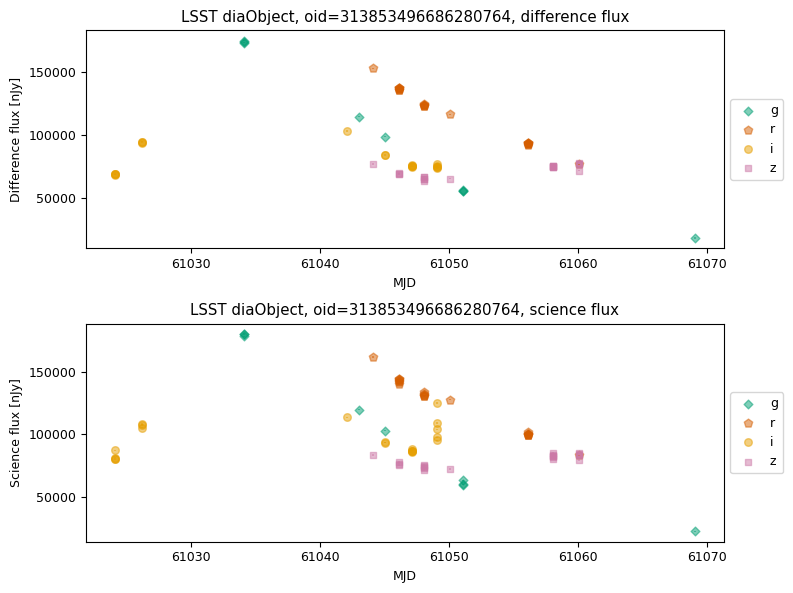

In [26]:
d_objs[sid][oid]['lc_kwargs']['show_forced'] = True

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

We can show these light curves using magnitude units

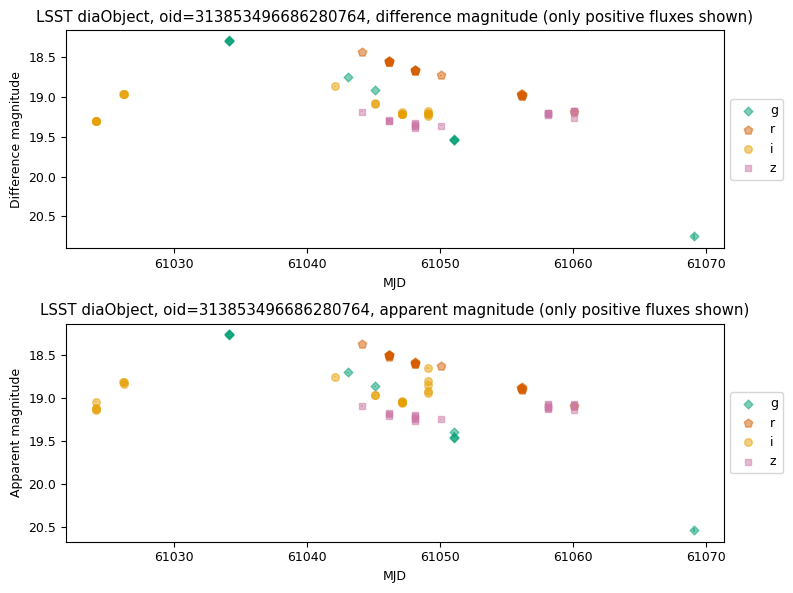

In [27]:
d_objs[sid][oid]['lc_kwargs']['show_flux'] = False
d_objs[sid][oid]['lc_kwargs']['show_forced'] = False

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

We can also show them using absolute magnitudes, assuming the redshift of the tentative host and the Planck 2018 cosmology

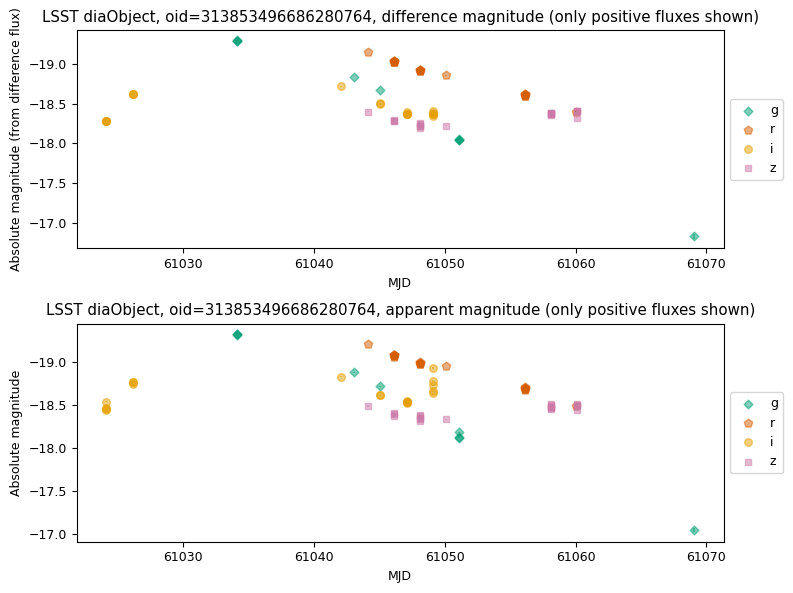

In [28]:
d_objs[sid][oid]['lc_kwargs']['show_absolute_mag'] = True
d_objs[sid][oid]['lc_kwargs']['z_obj'] = z_obj
d_objs[sid][oid]['lc_kwargs']['cosmo'] = Planck18

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

#### Stamps <a class='anchor' id='stamps'></a>

We show alert image cutouts for the first three detections of this object that triggered alerts. Note that not all stored detections may have triggered an alert, as they may come in an alert as previous detections. The field ```has_stamp``` in our detections dataframe indicates that a given detection triggered an alert, so that we can use it as a mask as

In [29]:
mask = epochs['detections']['has_stamp']
df_dets_this = epochs['detections'][mask].sort_values(by='mjd').iloc[0:3].copy()

cols = ['sid', 'measurement_id', 'band_name', 'mjd',
        'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr',
        'has_stamp']
cols = [x.lower() for x in cols]
display(df_dets_this[cols])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr,has_stamp
oid,,,,,,,,,
313853496686280764,1,313853496686280764,i,61024.131420,69393.812500,434.881348,87073.445312,451.603729,True
313853496686280764,1,313853498027933784,i,61024.138132,68777.632812,369.121277,80362.007812,372.005737,True
313853496686280764,1,313853498568474633,i,61024.140180,68613.234375,369.339661,79989.171875,374.356750,True


We use the ALeRCE client to retrieve the stamps, obtaining the main fields: Science, Template and Difference

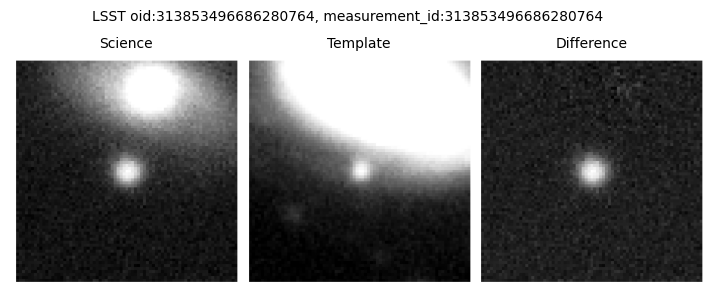

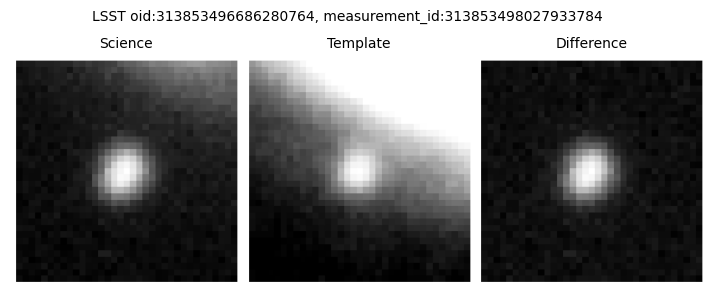

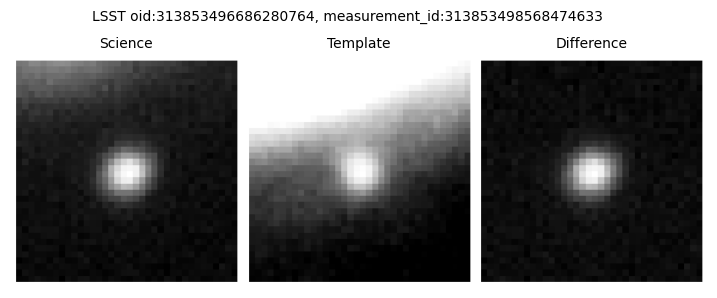

In [30]:
for i, row in df_dets_this.iterrows():
    params = {
        'survey': 'lsst',
        'oid': i,
        'measurement_id': row['measurement_id'],
    }
    df_stamps = alerce_client.plot_stamps(**params)

We show the same stamps, but using a custom function defined in ```alerce_multisurvey_tools.py```. This requires querying the stamps using the client function ```get_stamps```, that also retrieves the stamps headers

In [31]:
fontsize = 8

In [32]:
def set_title(oid=None, sid=None, row=None):
    col_flux = 'psfflux'
    col_flux_err = 'psffluxerr'

    title = ms.sid_num2str[sid] + ', oid=' + str(oid) + ', ' \
            + 'measurement_id=' + str(row['measurement_id']) + '\n' \
            + 'band=' + row['band_name'] + ', ' \
            + 'mjd=%.4f' % row['mjd'] + ', ' \
            + 'S/N=%.2f' % row['snr'] + ', ' \
            + 'psfFlux=%.f' % row[col_flux] + '+-' \
            + '%.f uJy' % row[col_flux_err]

    return title

In [33]:
df_stamps = ms.query_stamps(client=alerce_client, df_objs=df_dets_this, survey='lsst', sid=1)
print(df_stamps.columns)

Index(['measurement_id', 'flux_Science_data', 'flux_Science_header',
       'flux_Template_data', 'flux_Template_header', 'flux_Difference_data',
       'flux_Difference_header'],
      dtype='object')


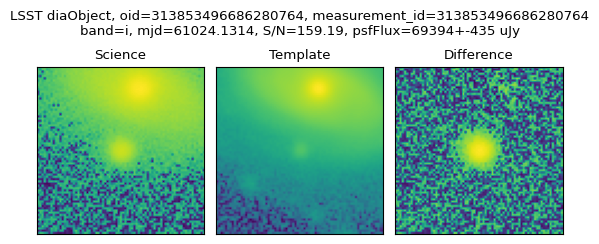

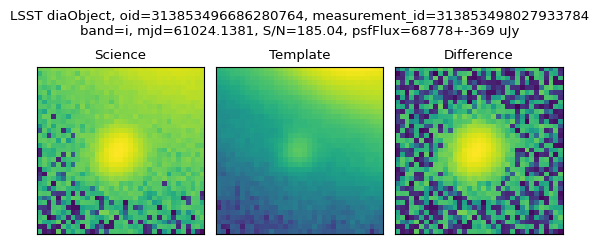

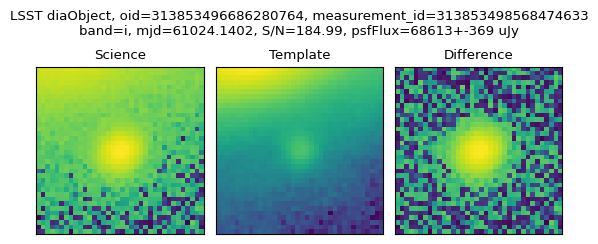

In [34]:
for i, row_this in df_dets_this.iterrows():
    mask = df_stamps.loc[[i]]['measurement_id'] == row_this['measurement_id']
    obj = df_stamps.loc[[i]][mask]
    
    for i, row in obj.iterrows():
        title = set_title(oid=i, sid=sid, row=row_this)
        ms.plot_stamps(row, title=title, fontsize=fontsize)

Note that LSST images are not always aligned between epochs. We use the header WCS to show stamps including equatorial coordinates. We continue this section showing only stamps for the first detection

In [35]:
df_dets_this = df_dets_this[~df_dets_this.index.duplicated(keep='first')].copy()
display(df_dets_this)

,sid,measurement_id,mjd,ra,dec,band,created_date,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
313853496686280764,1,313853496686280764,61024.13142,9.352321,-42.46275,3,2026-02-19,0,2025121400756,176,313853496686280764,0,0.000002,0.000002,5.811162e-14,2549.337891,0.035994,3547.108154,0.033921,False,70119.429688,652.025391,False,False,False,159.188461,69393.8125,434.881348,NaN,1670.22644,1681,False,False,False,68759.984375,0.476512,9.352321,NaN,-42.46275,NaN,0.585214,NaN,-84.049362,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,87073.445312,451.603729,False,False,False,14675.601562,9.231125,0.457387,0.431268,0.006412,0.462593,0.435522,-0.000829,False,False,False,False,0.001248,0.999998,False,False,61081.910089,NaN,75,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i


We show the header for the Science cutout

In [36]:
row_this = df_stamps.iloc[0].copy()
display(row_this['flux_Science_header'])

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   75                                                  
NAXIS2  =                   75                                                  
EXTEND  =                    T                                                  
CUTMINX =                 2511                                                  
CUTMINY =                 3509                                                  
ROTPA   =     352.530439684183 / Pos angle in deg of focal plane +Y wrt North   
BUNIT   = 'nJy     '                                                            
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =      38.337831164878 / Pixel coordinate of reference point            
CRPIX2  =      38.1082627054

Having the header data, we can plot stamps including WCS axes

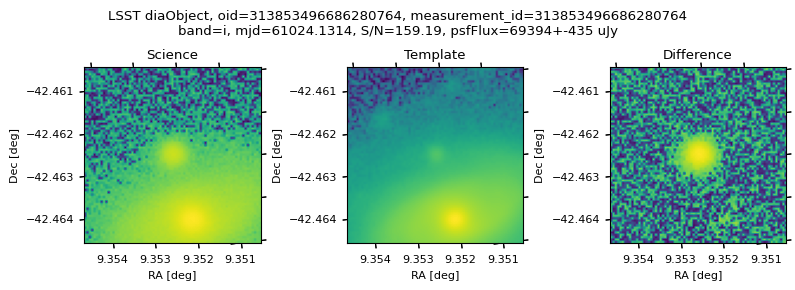

In [37]:
for j, row_this in df_dets_this.iterrows():
    mask = df_stamps.loc[[j]]['measurement_id'] == row_this['measurement_id']
    obj = df_stamps.loc[[j]][mask]
    
    for i, row in obj.iterrows():
        title = set_title(oid=i, sid=sid, row=row_this)
        ms.plot_stamps(row, title=title, fontsize=fontsize,
                       use_wcs=True, figsize=[8, 8], title_offset=0.68)

The client function ```multisurvey_get_stamps``` also allows to retrieve additional planes included in LSST stamps, i.e. variance and PSF. We can compute the image shape of each plane and cutout type

In [38]:
include_variance_and_psf = True

df_stamps = ms.query_stamps(
    client=alerce_client,
    df_objs=df_dets_this,
    survey='lsst',
    sid=sid,
    include_variance_and_psf=include_variance_and_psf
)
print(df_stamps.columns)

Index(['measurement_id', 'flux_Science_data', 'flux_Science_header',
       'flux_Template_data', 'flux_Template_header', 'flux_Difference_data',
       'flux_Difference_header', 'variance_Science_data',
       'variance_Science_header', 'variance_Template_data',
       'variance_Template_header', 'variance_Difference_data',
       'variance_Difference_header', 'psf_Science_data', 'psf_Science_header',
       'psf_Template_data', 'psf_Template_header', 'psf_Difference_data',
       'psf_Difference_header'],
      dtype='object')


In [39]:
cols = []
for plane in ms.image_planes:
    cols += [plane + '_' + x + '_data' for x in ms.image_subtypes]
#print(cols)

for col in cols:
    df_stamps[col.replace('data', 'shape')] = [x.shape for x in df_stamps[col]]
display(df_stamps[['measurement_id'] + [x.replace('data', 'shape') for x in cols]])

,measurement_id,flux_Science_shape,flux_Template_shape,flux_Difference_shape,variance_Science_shape,variance_Template_shape,variance_Difference_shape,psf_Science_shape,psf_Template_shape,psf_Difference_shape
oid,,,,,,,,,,
313853496686280764,313853496686280764,"(75, 75)","(75, 75)","(75, 75)","(75, 75)","(75, 75)","(75, 75)","(41, 41)","(43, 43)","(41, 41)"


We plot all planes for the stamps shown above

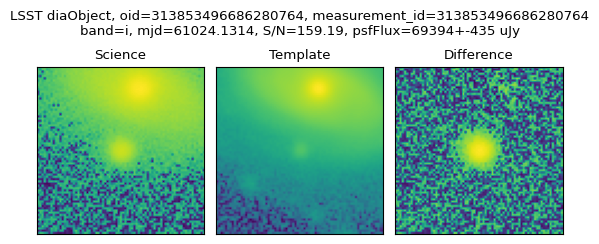

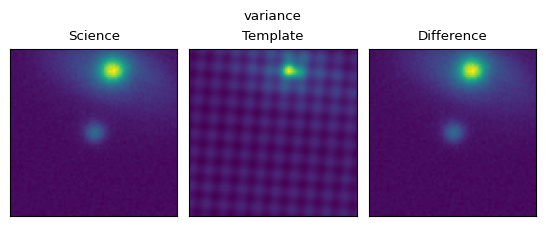

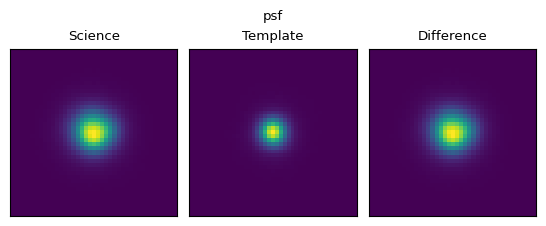

In [40]:
for j, row_this in df_dets_this.iterrows():
    mask = df_stamps.loc[[j]]['measurement_id'] == row_this['measurement_id']
    obj = df_stamps.loc[[j]][mask]
    
    for i, row in obj.iterrows():
        title = set_title(oid=i, sid=sid, row=row_this)
        for plane in ms.image_planes:
            title_aux = title if plane == 'flux' else plane
            title_offset = 0.72 if plane == 'flux' else 0.7
            ms.plot_stamps(row, plane=plane, title=title_aux,
                           fontsize=fontsize, title_offset=title_offset)

#### Latest diaObject information <a class='anchor' id='diaobject_latest'></a>

We query the latest record ingested by our pipeline for this object from the diaObject alert field as

In [41]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_dia_object
WHERE
    oid = %d
''' % oid
df_dia = alerce_tap.search(query).to_table().to_pandas()

display(df_dia)

,oid,validitystartmjdtai,ra,raerr,dec,decerr,ra_dec_cov,u_psffluxmean,u_psffluxmeanerr,u_psffluxsigma,u_psffluxndata,u_fpfluxmean,u_fpfluxmeanerr,g_psffluxmean,g_psffluxmeanerr,g_psffluxsigma,g_psffluxndata,g_fpfluxmean,g_fpfluxmeanerr,r_psffluxmean,r_psffluxmeanerr,r_psffluxsigma,r_psffluxndata,r_fpfluxmean,r_fpfluxmeanerr,i_psffluxmean,i_psffluxmeanerr,i_psffluxsigma,i_psffluxndata,i_fpfluxmean,i_fpfluxmeanerr,z_psffluxmean,z_psffluxmeanerr,z_psffluxsigma,z_psffluxndata,z_fpfluxmean,z_fpfluxmeanerr,y_psffluxmean,y_psffluxmeanerr,y_psffluxsigma,y_psffluxndata,y_fpfluxmean,y_fpfluxmeanerr,u_sciencefluxmean,u_sciencefluxmeanerr,g_sciencefluxmean,g_sciencefluxmeanerr,r_sciencefluxmean,r_sciencefluxmeanerr,i_sciencefluxmean,i_sciencefluxmeanerr,z_sciencefluxmean,z_sciencefluxmeanerr,y_sciencefluxmean,y_sciencefluxmeanerr,u_psffluxmin,u_psffluxmax,u_psffluxmaxslope,u_psffluxerrmean,g_psffluxmin,g_psffluxmax,g_psffluxmaxslope,g_psffluxerrmean,r_psffluxmin,r_psffluxmax,r_psffluxmaxslope,r_psffluxerrmean,i_psffluxmin,i_psffluxmax,i_psffluxmaxslope,i_psffluxerrmean,z_psffluxmin,z_psffluxmax,z_psffluxmaxslope,z_psffluxerrmean,y_psffluxmin,y_psffluxmax,y_psffluxmaxslope,y_psffluxerrmean,firstdiasourcemjdtai,lastdiasourcemjdtai,ndiasources,created_date
0,313853496686280764,61084.734613,9.352326,0.000002,-42.462751,0.000002,5.811162e-14,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,110478.46875,88.413109,21691.716797,20,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,117845.867188,89.553978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76731.84375,153166.21875,3707192.5,417.217438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64,2026-02-19


### Query a ssObject <a class='anchor' id='query_ssobject'></a>

We choose ```oid = ssObjectId = 21165806405629509```, which has the unpacked designation "2020 TE16"

In [42]:
oid = 21165806405629509
sid = 2

We query its main properties and light curve as before

In [43]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    oid = %d
    AND sid = %d
''' % (oid, sid)

df_obj = alerce_tap.search(query).to_table().to_pandas()
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,21165806405629509,1,2,151.183383,1.910332,0.000002,0.000002,61094.120903,61098.272697,4.151794,91,0,0,2026-02-23,2026-02-27


In [44]:
query = '''
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.oid = %d
''' % oid
df_dets = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_dets.drop(columns=cols, inplace=True)
#display(df_dets)

In [45]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

In [46]:
display(df_dets)

,sid,measurement_id,mjd,ra,dec,band,created_date,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
21165806405629509,2,170046089996009515,61094.120903,151.668616,1.706979,3,2026-02-23,0,2026022200146,181,0,21165806405629509,0.000026,0.000032,-2.072009e-10,3327.888916,0.431156,1581.281494,0.597988,False,1699.175049,547.820679,False,False,False,8.144222,1833.400635,228.514908,NaN,1684.797852,1681,False,False,False,2123.717285,16.379791,151.668598,NaN,1.706993,NaN,1.530713,NaN,-0.962792,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1778.448364,220.138016,False,False,False,-16.749313,28.033731,0.125818,0.294704,-0.100408,0.268078,0.193955,-0.016782,False,False,False,False,0.045627,0.573673,False,False,61094.122650,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i
21165806405629509,2,170046090132324364,61094.121367,151.668535,1.707034,3,2026-02-23,0,2026022200147,185,0,21165806405629509,0.000024,0.000025,-5.503898e-11,1303.993164,0.420428,269.183990,0.468560,False,1261.222778,569.349548,False,False,False,7.464016,1874.825195,245.177734,NaN,1643.801514,1681,False,False,False,2070.696289,10.576172,151.668532,NaN,1.707042,NaN,1.424796,NaN,19.212830,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1791.113159,230.847763,False,False,False,-49.262611,22.798962,0.302656,0.279428,-0.100698,0.301219,0.201256,-0.012052,False,False,False,False,0.146231,0.374304,False,False,61094.123087,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i
21165806405629509,2,170046092939886678,61094.135633,151.665270,1.708348,1,2026-02-23,0,2026022200168,164,0,21165806405629509,0.000021,0.000034,3.272867e-11,380.551941,0.613806,3586.365479,0.380849,False,235.333450,253.030640,False,False,False,6.241818,770.311951,120.697449,NaN,1735.695190,1681,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,709.401245,118.343590,False,False,False,-82.854477,8.553704,NaN,NaN,NaN,0.298262,0.240823,0.029016,True,False,False,False,NaN,0.289569,False,False,61094.137680,NaN,16,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,g
21165806405629509,2,170046101807169593,61094.173948,151.656393,1.711889,1,2026-02-23,0,2026022200234,181,0,21165806405629509,0.000032,0.000033,-4.918111e-11,2036.903320,0.563729,2106.301270,0.596836,False,1067.111694,249.894257,False,False,False,7.531261,906.270

#### Epoch data from the ssSource alert field, and latest mpc_orbits information <a class='anchor' id='tables_sso'></a>

We retrieve additional information for this object from the ssSource alert field, which is stored in our ```lsst_ss_detection``` table

In [47]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_ss_detection
WHERE
    ssObjectId = %d
''' % oid
df_ssd = alerce_tap.search(query).to_table().to_pandas()

display(df_ssd)

,measurement_id,ssobjectid,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
0,170063723605524549,21165806405629509,K20T16E,152.051960,-9.246543,237.442655,42.570323,168.853409,3.638510,1.363054e-08,0.0,2.016633e-08,0.001412,150.751254,2.095065,0.0,0.0,0.0,0.0,0.945613,0.925363,-0.194643,NaN,NaN,-1.803613e-08,8.900247e-09,1.471261e-09,-0.005126,-0.006708,-0.002905,0.010782,-1.188479e-08,6.655458e-09,4.983003e-10,0.001489,0.008249,0.003478,0.011761,1,2026-02-27
1,170050500789534739,21165806405629509,K20T16E,152.807675,-9.278414,238.316644,42.951882,170.431412,3.130459,1.358330e-08,0.0,2.013665e-08,0.001434,151.438348,1.802139,0.0,0.0,0.0,0.0,0.853850,0.766634,-0.375942,NaN,NaN,-1.792826e-08,9.039675e-09,1.531766e-09,-0.005217,-0.006662,-0.002897,0.010770,-1.192436e-08,6.491020e-09,4.271687e-10,0.002437,0.007898,0.003340,0.011432,1,2026-02-24
2,170050498379907088,21165806405629509,K20T16E,152.810164,-9.278412,238.319463,42.953215,170.434433,3.129483,1.358319e-08,0.0,2.013656e-08,0.001434,151.440595,1.801228,0.0,0.0,0.0,0.0,0.979069,0.953510,-0.222249,NaN,NaN,-1.792792e-08,9.040114e-09,1.531957e-09,-0.005217,-0.006662,-0.002897,0.010770,-1.192452e-08,6.490501e-09,4.269491e-10,0.002450,0.007887,0.003339,0.011420,1,2026-02-24
3,170050496896172060,21165806405629509,K20T16E,152.811784,-9.278484,238.321352,42.954021,170.436462,3.128829,1.358311e-08,0.0,2.013649e-08,0.001434,151.442109,1.800613,0.0,0.0,0.0,0.0,0.846815,0.795681,-0.289806,NaN,NaN,-1.792769e-08,9.040408e-09,1.532085e-09,-0.005217,-0.006662,-0.002897,0.010770,-1.192462e-08,6.490152e-09,4.268011e-10,0.002458,0.007879,0.003339,0.011411,1,2026-02-24
4,170050495695028255,21165806405629509,K20T16E,152.812833,-9.278490,238.322545,42.954577,170.437744,3.128415,1.358306e-08,0.0,2.013645e-08,0.001434,151.443068,1.800224,0.0,0.0,0.0,0.0,0.852845,0.821748,-0.228199,NaN,NaN,-1.792754e-08,9.040596e-09,1.532167e-09,-0.005218,-0.006662,-0.002897,0.010770,-1.192469e-08,6.489931e-09,4.267074e-10,0.002463,0.007874,0.003339,0.011405,1,2026-02-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,170059304644116563,21165806405629509,K20T16E,152.294949,-9.258484,237.723653,42.692469,169.491165,3.433323,1.361312e-08,0.0,2.015677e-08,0.001419,150.971684,1.999504,0.0,0.0,0.0,0.0,0.933924,0.873390,-0.330763,NaN,NaN,-1.800143e-08,8.945462e-09,1.490855e-09,-0.005156,-0.006693,-0.002902,0.010778,-1.189580e-08,6.601635e-09,4.749733e-10,0.001759,0.008160,0.003435,0.011674,1,2026-02-26
87,170059305179938929,21165806405629509,K20T16E,152.294488,-9.258448,237.723109,42.692249,169.490051,3.433678,1.361316e-08,0.0,2.015679e-08,0.001419,150.971264,1.999680,0.0,0.0,0.0,0.0,0.934286,0.895214,-0.267363,NaN,NaN,-1.800150e-08,8.945379e-09,1.490819e-09,-0.005156,-0.006693,-0.002902,0.010778,-1.189577e-08,6.601737e-09,4.750162e-10,0.001756,0.008160,0.003435,0.011673,1,2026-02-26
88,170059306126278673,21165806405629509,K20T16E,152.293651,-9.258394,237.722129,42.691841,169.488052,3.434321,1.361321e-08,0.0,2.015682e-08,0.001419,150.970506,1.999997,0.0,0.0,0.0,0.0,0.925807,0.908405,-0.178662,NaN,NaN,-1.800161e-08,8.945228e-09,1.490753e-09,-0.005155,-0.006693,-0.002902,0.010778,-1.189574e-08,6.601921e-09,4.750936e-10,0.001750,0.008161,0.003436,0.011673,1,2026-02-26
89,170059308243877918,21165806405629509,K20T16E,152.289482,-9.258288,237.717372,42.689669,169.477982,3.437560,1.361350e-08,0.0,2.015699e-08,0.001419,150.966693,2.001597,0.0,0.0,0.0,0.0,0.968720,0.898580,-0.361902,NaN,NaN,-1.800220e-08,8.944468e-09,1.490424e-09,-0.005155,-0.006693,-0.002902,0.010778,-1.189554e-08,6

And also the latest mpc_orbits alert field information, stored in our ```lsst_mpc_orbits``` table

In [48]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_mpc_orbits
WHERE
    ssObjectId = %d
''' % oid
df_mpc = alerce_tap.search(query).to_table().to_pandas()

display(df_mpc)

,ssobjectid,designation,packed_primary_provisional_designation,unpacked_primary_provisional_designation,mpc_orb_jsonb,created_at,updated_at,orbit_type_int,u_param,nopp,arc_length_total,arc_length_sel,nobs_total,nobs_total_sel,a,q,e,i,node,argperi,peri_time,yarkovsky,srp,a1,a2,a3,dt,mean_anomaly,period,mean_motion,a_unc,q_unc,e_unc,i_unc,node_unc,argperi_unc,peri_time_unc,yarkovsky_unc,srp_unc,a1_unc,a2_unc,a3_unc,dt_unc,mean_anomaly_unc,period_unc,mean_motion_unc,epoch_mjd,h,g,not_normalized_rms,normalized_rms,earth_moid,fitting_datetime,created_date,updated_date
0,21165806405629509,2020 TE16,K20T16E,2020 TE16,"{""CAR"": {""covariance"": {""cov00"": 0.00000000002690110152166777, ""cov01"": 0.0000000000102575724806...",1970-01-01,1970-01-01,-1,0,4,0.0,0.0,63,63,0.0,1.925311,0.242377,6.321986,234.830867,130.788252,60558.180433,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000005,0.000002,0.000042,0.000197,0.000525,0.001386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60600.0,19.474,0.15,0.0,0.637635,0.9307,1970-01-01,2026-02-27,2026-02-27


We show its detections coordinates in different systems, colored by MJD and difference flux. For this we define a function and merge epoch tables

In [49]:
def plot_scatter(df=None, title='', prop_x=None, prop_y=None,
                 prop_color=None, figsize=(6, 3), alpha=0.7):
    fontsize = 9
    plt.rcParams.update({'font.size': fontsize})
    
    fig, ax = plt.subplots(figsize=figsize)

    if prop_color is None:
        sc = ax.scatter(df[prop_x], df[prop_y], s=3, alpha=alpha)
    else:
        cmap = 'coolwarm'
        sc = ax.scatter(df[prop_x], df[prop_y],
                        c=df[prop_color],
                        cmap=cmap, s=10, alpha=alpha)
        plt.colorbar(sc, ax=ax, label=prop_color)
    
    ax.set_xlabel(prop_x)
    ax.set_ylabel(prop_y)
    ax.set_title(title)
    
    plt.tight_layout()
    plt.rcParams.update({'font.size': 12})

In [50]:
cols = ['ssObjectId', 'measurement_id']
cols = [x.lower() for x in cols]

df_dets_sso = pd.merge(df_dets.reset_index(), df_ssd,
                       on=cols)
col = 'created_date'
df_dets_sso = df_dets_sso.drop(
    columns=[col + '_x']).rename(columns={col + '_y': col}).copy()
del df_dets, df_ssd

display(df_dets_sso)

,oid,sid,measurement_id,mjd,ra,dec,band,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
0,21165806405629509,2,170046089996009515,61094.120903,151.668616,1.706979,3,0,2026022200146,181,0,21165806405629509,0.000026,0.000032,-2.072009e-10,3327.888916,0.431156,1581.281494,0.597988,False,1699.175049,547.820679,False,False,False,8.144222,1833.400635,228.514908,NaN,1684.797852,1681,False,False,False,2123.717285,16.379791,151.668598,NaN,1.706993,NaN,1.530713,NaN,-0.962792,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1778.448364,220.138016,False,False,False,-16.749313,28.033731,0.125818,0.294704,-0.100408,0.268078,0.193955,-0.016782,False,False,False,False,0.045627,0.573673,False,False,61094.122650,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i,K20T16E,153.059685,-9.285809,238.608336,43.080044,170.656433,3.058232,1.357201e-08,0.0,2.012674e-08,0.001440,151.668381,1.707074,0.0,0.0,0.0,0.0,0.911854,0.844816,-0.343167,NaN,NaN,-1.789218e-08,9.085569e-09,1.551737e-09,-0.005247,-0.006647,-0.002895,0.010766,-1.194100e-08,6.438067e-09,4.043056e-10,0.002723,0.007754,0.003290,0.011299,1,2026-02-23
1,21165806405629509,2,170046090132324364,61094.121367,151.668535,1.707034,3,0,2026022200147,185,0,21165806405629509,0.000024,0.000025,-5.503898e-11,1303.993164,0.420428,269.183990,0.468560,False,1261.222778,569.349548,False,False,False,7.464016,1874.825195,245.177734,NaN,1643.801514,1681,False,False,False,2070.696289,10.576172,151.668532,NaN,1.707042,NaN,1.424796,NaN,19.212830,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1791.113159,230.847763,False,False,False,-49.262611,22.798962,0.302656,0.279428,-0.100698,0.301219,0.201256,-0.012052,False,False,False,False,0.146231,0.374304,False,False,61094.123087,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i,K20T16E,153.059588,-9.285786,238.608208,43.080012,170.656372,3.058254,1.357202e-08,0.0,2.012674e-08,0.001440,151.668275,1.707117,0.0,0.0,0.0,0.0,0.980570,0.934575,-0.296797,NaN,NaN,-1.789220e-08,9.085548e-09,1.551728e-09,-0.005247,-0.006647,-0.002895,0.010766,-1.194099e-08,6.438091e-09,4.043158e-10,0.002723,0.007755,0.003290,0.011300,1,2026-02-23
2,211

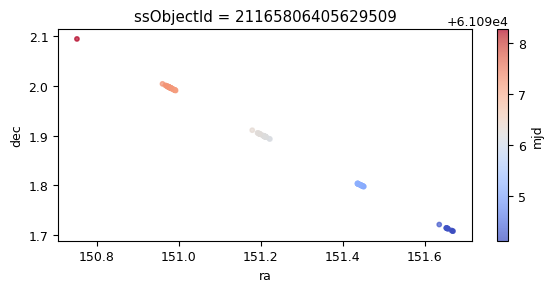

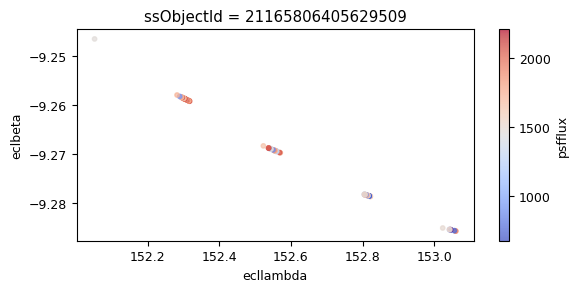

In [51]:
props_x = ['ra', 'eclLambda']
props_x = [x.lower() for x in props_x]
props_y = ['dec', 'eclBeta']
props_y = [x.lower() for x in props_y]
props_color = ['mjd', 'psfFlux']
props_color = [x.lower() for x in props_color]
title = 'ssObjectId = ' + str(oid)

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_dets_sso, title=title,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color)

### Cone search <a class='anchor' id='conesearch'></a>

Let us say we want to know if the known RRLab star SSS_J004408.1-432806 has triggered Rubin alerts. This star has equatorial coordinates (11.03301, -43.46871) deg and a period of 0.546472 d in VSX (see https://vsx.aavso.org/index.php?view=detail.top&oid=479455). We use a cone search with a small radius (e.g. 1.5 arcsec)

In [52]:
ra = 11.03301
dec = -43.46871
period = 0.546472
radius = 1.5

Note that you need to provide object coordinates in equatorial system in deg, and search radius in arcsec

In [53]:
df_obj = alerce_client.query_objects(
    survey='lsst',
    ra=ra,
    dec=dec,
    radius=radius
)
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,stellar,class_name,classifier_name,classfier_version,probability,ranking
0,313629129709715483,1,1,11.033297,-43.468727,4.283685e-07,4.236282e-07,60973.170251,61060.081744,86.911493,39,0,0,None,VS,stamp_classifier_rubin_beta,None,0.984722,1


In tap, this becomes (using search radius in deg)

In [54]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    DISTANCE(%g, %g, meanra, meandec) < %g
''' % (ra, dec, radius / 3600)
df_obj = alerce_tap.search(query).to_table().to_pandas()

display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,313629129709715483,1,1,11.033297,-43.468727,4.283685e-07,4.236282e-07,60973.170251,61060.081744,86.911493,39,0,0,2026-02-13,2026-02-24


Now that we know the object identifier in LSST (and its ```sid```) we can query other data as before. In particular, we obtain its light curve and show it also as a folded light curve using the known period

In [55]:
oid = df_obj.iloc[0]['oid']
sid = df_obj.iloc[0]['sid']

In [56]:
df_dets = alerce_client.query_detections(oid, survey='lsst',
                                         format='pandas')
display(df_dets)

,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,psfFluxErr,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,scienceFlux,scienceFluxErr,has_stamp,visit,detector,ssObjectId,raErr,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfLnL,psfChi2,psfNdata,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,3,60973.170251,lsst,11.033278,-43.468735,313629129709715483,313629129709715483,0,313629129709715483,33248.160,519.14417,0,0,0,134026.53,550.59240,True,2025102400260,114,0,0.000005,0.000006,-3.776119e-13,3027.14720,0.099165,2078.81800,0.086456,False,33205.824,682.27300,False,False,False,63.852493,None,1558.3109,1681,32727.422,0.901845,11.033278,None,-43.468735,None,0.935255,None,163.976820,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,99079.305,6.257832,0.552269,0.483983,-0.016753,0.561423,0.495099,-0.022474,False,False,False,False,0.004855,0.953479,False,False,61081.913394,None,46,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
1,1,60985.230983,lsst,11.033313,-43.468695,313629129709715483,313681911507582991,0,313629129709715483,37216.777,1060.50040,0,0,0,119017.06,1155.06070,True,2025110500299,124,0,0.000014,0.000016,1.717819e-11,3998.23360,0.245487,1315.31930,0.292089,False,36573.418,1273.32650,False,False,False,35.011997,None,1683.1191,1681,42238.754,0.554851,11.033313,None,-43.468696,None,1.825352,None,12.985518,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,79312.230,4.522082,1.101247,1.398299,0.002013,1.026416,1.094702,-0.004008,False,False,False,False,0.570685,0.601747,False,False,61081.979479,None,62,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,g
2,1,60985.231420,lsst,11.033364,-43.468729,313629129709715483,313681911641800716,0,313629129709715483,36954.535,955.31450,0,0,0,115490.46,1005.50840,True,2025110500300,124,0,0.000011,0.000012,7.162491e-12,3999.88160,0.191681,1314.09200,0.217387,False,36129.395,1185.94740,False,False,False,38.629536,None,1676.4487,1681,38975.496,5.600237,11.033369,None,-43.468725,None,1.177886,None,-156.997010,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,77631.766,3.691063,0.856921,0.970321,-0.019819,0.838971,0.968011,0.037384,False,False,False,False,0.002841,0.991222,False,False,61081.944779,None,53,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,g
3,1,60991.237160,lsst,11.033339,-43.468733,313629129709715483,313708285430071331,0,313629129709715483,37629.850,317.62115,0,0,0,113694.23,324.51680,True,2025111100192,133,0,0.000002,0.000002,-2.287745e-13,3358.41330,0.040580,2181.60620,0.038183,False,38099.770,384.06613,False,False,False,119.551346,None,1878.9166,1681,35855.695,0.028093,11.033336,No

In [57]:
df_forced = alerce_client.query_forced_photometry(oid, survey='lsst',
                                                  format='pandas')
display(df_forced)

""


In [58]:
lc_params = {
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [59]:
df_dets.set_index('oid', inplace=True)
if len(df_forced) > 0:
    df_forced.set_index('oid', inplace=True)

epochs = {
    'detections': df_dets,
    'forced_photometry': df_forced,

}
d_objs = ms.group_data_sid_oid(
    sid=sid,
    oid=oid,
    df_dets=epochs['detections'].copy(),
    df_forced=epochs['forced_photometry'].copy() \
        if oid in epochs['forced_photometry'].index else pd.DataFrame(),
        lc_kwargs=ms.init_lc_kwargs()
    )

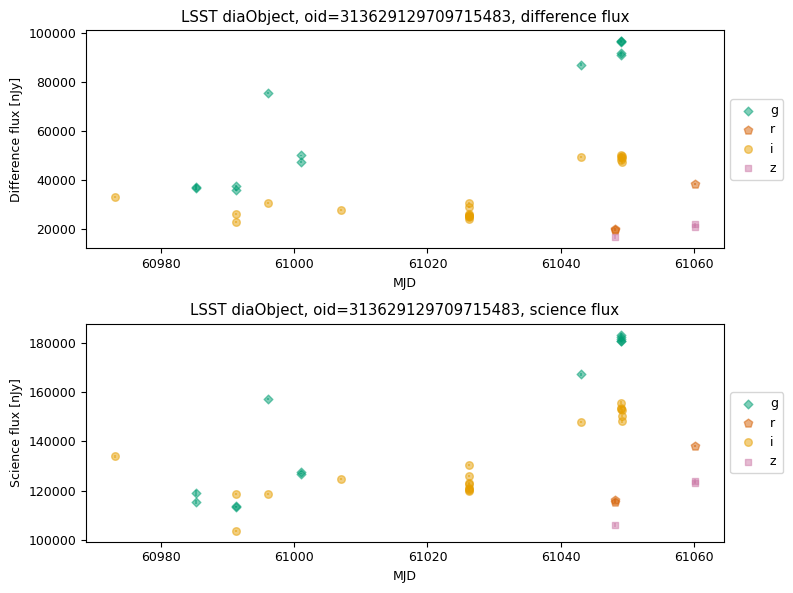

In [60]:
d_objs[sid][oid]['lc_kwargs']['show_forced'] = True

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

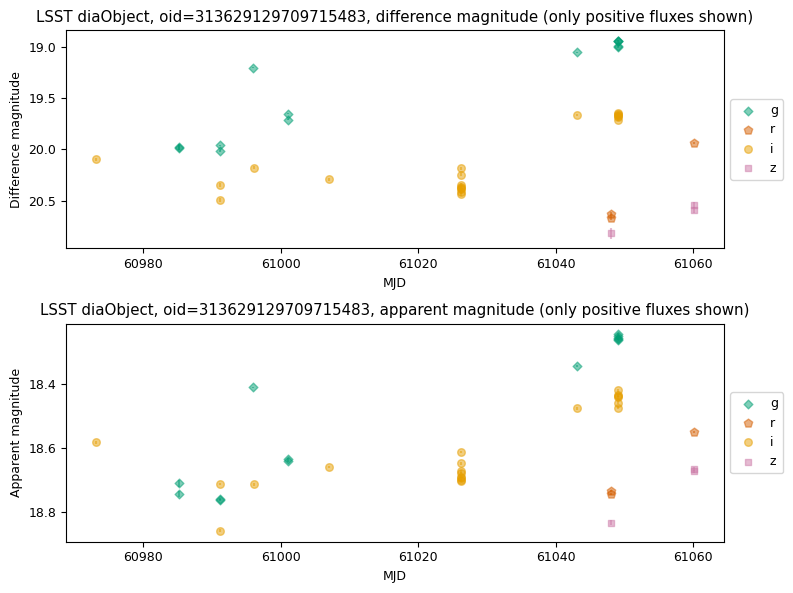

In [61]:
d_objs[sid][oid]['lc_kwargs']['show_flux'] = False
d_objs[sid][oid]['lc_kwargs']['show_forced'] = False

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

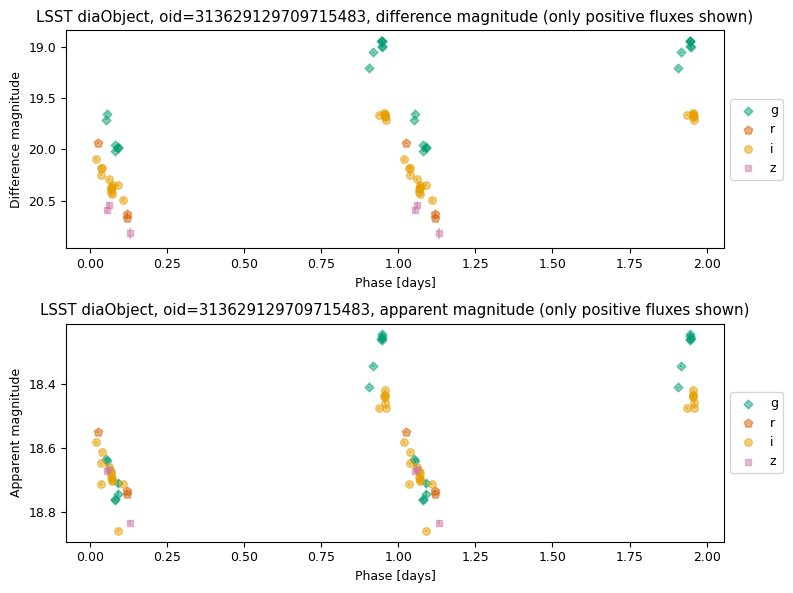

In [62]:
d_objs[sid][oid]['lc_kwargs']['show_folded'] = True
d_objs[sid][oid]['lc_kwargs']['folded_period'] = period

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

## How to query LSST and ZTF data for a given object <a class='anchor' id='query_one_lsst_ztf'></a>

Here we illustrate a cone search through the ALeRCE client as an example. This case is useful to explore LSST and ZTF data for an object from an external catalog whose equatorial coordinates are known. Along this example we show how to query several properties, like basic statistics and light curves.

Let us say we want to know if the known supernova [SN 2026asx](https://www.wis-tns.org/object/2026asx) has triggered Rubin and/or ZTF alerts. This object has equatorial coordinates (187.020186, 6.967836) deg, and was reported by ALeRCE to the [Transient Name Server](https://www.wis-tns.org/) based on ZTF detections. According to the TNS report, its host (LEDA 1311098) has redshift $z = 0.076$. We use a cone search with a small radius (e.g. 1.5 arcsec)

In [63]:
ra = 187.020186
dec = 6.967836
z_obj = 0.076
radius = 1.5

Note that you need to provide object coordinates in equatorial system in deg, and search radius in arcsec. If found, this query will return the main properties of the matching object

In [64]:
df_obj_lsst = alerce_client.query_objects(
    survey='lsst',
    ra=ra,
    dec=dec,
    radius=radius
)
df_obj_lsst

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,stellar,class_name,classifier_name,classfier_version,probability,ranking
0,170028526513684557,1,1,187.020189,6.967839,1.241193e-07,1.279507e-07,61090.247937,61098.241373,7.993435,526,552,0,None,SN,stamp_classifier_rubin_beta,None,0.984521,1


In [65]:
df_obj_ztf = alerce_client.query_objects(
    survey='ztf',
    ra=ra,
    dec=dec,
    radius=radius
)
df_obj_ztf

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,g_r_mean,g_r_mean_corr,firstmjd,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF26aacextk,23,2217,61058.43963,61078.519271,False,False,6,None,None,None,None,61059.56081,61078.519271,18.958461,187.020241,6.967839,0.030032,0.02981,None,None,None,27.5.7a32.dev1


Now that we know the object identifiers in LSST and ZTF we can query its detections in each survey. For LSST we use its ```sid``` from the output table, while for ZTF we use ```sid = 0```

In [66]:
oid_lsst = df_obj_lsst.loc[0, 'oid']
oid_ztf = df_obj_ztf.loc[0, 'oid']

In [67]:
sid_lsst = df_obj_lsst.loc[0, 'sid']
sid_ztf = 0

### Generate ALeRCE Explorer links <a class='anchor' id='explorer_url'></a>

Note that the interfaces accept a maximum of 200 objects

In [68]:
def print_link_lsst(index=None):
    if len(index) == 1:
        expr = 'https://lsst.alerce.online/object/' + str(index[0]) \
               + '?survey=lsst'
    else:
        expr1 = 'https://lsst.alerce.online/?oid='
        expr2 = ','.join(list([str(x) for x in index]))
        expr3 = '&survey=lsst'
        expr = expr1 + expr2 + expr3
    
    display(HTML("<a href='%s' target=\"_blank\"> %s <a>" % (expr, expr)))

In [69]:
def print_link_ztf(index=None, classifier=None):
    expr1 = 'https://alerce.online/?oid='
    expr2 = '&oid='.join(list(index))
    expr3 = '&selectedClassifier=' + classifier + '_classifier&page=1'
    expr = expr1 + expr2 + expr3

    display(HTML("<a href='%s' target=\"_blank\"> %s <a>" % (expr, expr)))

In [70]:
print_link_lsst(index=[oid_lsst])
print_link_ztf(index=[oid_ztf], classifier='stamp')

### Light curves <a class='anchor' id='light_curves'></a>

We obtain its light curve (detections and forced photometry points) by using the ```query_detections``` and ```query_forced_photometry``` functions

In [71]:
df_dets_lsst = alerce_client.query_detections(
    oid_lsst,
    survey='lsst',
    format='pandas'
)
display(df_dets_lsst)

,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,psfFluxErr,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,scienceFlux,scienceFluxErr,has_stamp,visit,detector,ssObjectId,raErr,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfLnL,psfChi2,psfNdata,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,3,61090.247937,lsst,187.020188,6.967830,170028526513684557,170028526513684557,0,170028526513684557,28242.050,365.80746,0,0,0,75483.920,368.47670,False,2026021800360,145,NaN,0.000003,0.000003,-1.429093e-12,1327.68700,0.053634,2865.55760,0.062551,False,28883.625,685.58203,False,False,False,76.423260,None,1775.4773,1681,27233.220,0.699775,187.020189,None,6.967829,None,0.733123,None,114.661380,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,46383.430,23.967625,0.258646,0.304292,0.005605,0.265069,0.314855,0.003109,False,False,False,False,0.006199,0.999984,False,False,61090.249555,None,33,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
1,3,61090.248460,lsst,187.020186,6.967837,170028526513684557,170028526648426560,0,170028526513684557,28295.225,378.44610,0,0,0,77013.450,380.54254,False,2026021800361,146,NaN,0.000004,0.000003,5.497801e-13,1304.35960,0.064978,2940.49830,0.061851,False,30203.986,692.92170,False,False,False,74.090126,None,1606.1893,1681,26824.934,0.011511,187.020187,None,6.967838,None,0.548408,None,103.760250,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,48106.562,18.704697,0.323573,0.324159,0.012824,0.321277,0.301220,0.005265,False,False,False,False,0.012710,0.999961,False,False,61090.250148,None,39,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
2,3,61090.248928,lsst,187.020187,6.967841,170028526513684557,170028526761672712,0,170028526513684557,29842.018,374.21810,0,0,0,76596.060,375.63130,False,2026021800362,106,NaN,0.000003,0.000003,2.398282e-13,1211.58670,0.059730,388.13254,0.058319,False,31890.660,689.67316,False,False,False,79.224450,None,1826.5992,1681,28082.600,0.376741,187.020187,None,6.967841,None,0.315864,None,98.725360,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,46111.094,23.524155,0.321203,0.320733,0.004183,0.313450,0.294817,0.003391,False,False,False,False,0.023009,0.999987,False,False,61090.250538,None,58,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
3,3,61090.249392,lsst,187.020190,6.967834,170028526513684557,170028526916337670,0,170028526513684557,28559.727,388.38940,0,0,0,80759.650,391.18463,False,2026021800363,145,NaN,0.000004,0.000004,-1.031545e-12,2570.11230,0.064965,299.62250,0.070066,False,30070.717,691.36880,False,False,False,72.395950,None,1588.3430,1681,26803.895,0.140040,187.020191,None,6

In [72]:
df_dets_ztf = alerce_client.query_detections(
    oid_ztf,
    survey='ztf',
    format='pandas'
)
df_dets_ztf['oid'] = oid_ztf
display(df_dets_ztf)

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,magap,sigmapsf,sigmagap,ra,dec,rb,rbversion,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,oid
0,ztf,61059.560810,3305560815515015025,1,3305560815515,20.492268,1,3305,1.491836,20.141708,20.1365,0.183754,0.2805,187.020236,6.967859,0.764286,t17_f5_c3,0.999971,20.1899,0.3743,473120155.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
1,ztf,61061.454224,3307454225515015023,1,3307454225515,20.578934,1,3307,1.715862,20.073265,20.1090,0.212786,0.2520,187.020232,6.967944,0.820000,t17_f5_c3,0.999997,20.0094,0.2916,473120155.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
2,ztf,61061.543889,3307543885515015017,2,3307543885515,19.945002,1,3307,4.528496,19.761988,19.4851,0.160267,0.2668,187.020187,6.967794,0.800000,t17_f5_c3,0.999894,19.4458,0.3278,473120255.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
3,ztf,61069.459850,3315459845515015013,2,3315459845515,19.763500,1,3315,4.357890,19.411000,19.3742,0.213132,0.2418,187.020296,6.967851,0.818571,t17_f5_c3,NaN,19.3053,0.2897,NaN,False,False,False,27.5.7a32.dev1,0.0,3.324519e+18,NaN,NaN,NaN,ZTF26aacextk
4,ztf,61069.508484,3315508485515015025,1,3315508485515,20.310700,1,3315,1.355290,19.838900,20.2155,0.237601,0.3167,187.020254,6.967780,0.755714,t17_f5_c3,NaN,20.4713,0.5091,NaN,False,True,True,27.5.7a32.dev1,0.0,3.324519e+18,19.182226,0.125228,0.129771,ZTF26aacextk
5,ztf,61078.519271,3324519275515015004,2,3324519275515,19.720327,1,3324,4.301351,19.594992,19.7324,0.179135,0.3838,187.020239,6.967757,0.795714,t17_f5_c3,0.999995,19.3882,0.3575,473120255.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk


In [73]:
df_forced_lsst = alerce_client.query_forced_photometry(
    oid_lsst,
    survey='lsst',
    format='pandas'
)
display(df_forced_lsst)

,band,mjd,survey_id,oid,measurement_id,ra,dec,visit,detector,psfFlux,psfFluxErr,scienceFlux,scienceFluxErr,band_name
0,1,61098.188817,lsst,170028526513684557,170063705381798181,187.020189,6.967841,2026022600319,143,5469.8164,256.19998,16982.256,255.93236,g
1,1,61098.189287,lsst,170028526513684557,170063705514442935,187.020189,6.967841,2026022600320,140,6190.8896,271.20230,18513.541,271.73430,g
2,2,61098.191128,lsst,170028526513684557,170063705652331018,187.020189,6.967841,2026022600321,147,20813.4410,273.55080,38538.383,272.49673,r
3,2,61098.191596,lsst,170028526513684557,170063705784975748,187.020189,6.967841,2026022600322,144,20225.4530,266.18997,36988.445,264.92770,r
4,2,61098.192064,lsst,170028526513684557,170063705919193743,187.020189,6.967841,2026022600323,144,20715.6270,268.76886,37890.176,267.13700,r
5,2,61098.192530,lsst,170028526513684557,170063706053411247,187.020189,6.967841,2026022600324,144,20444.4120,268.54324,37835.600,266.92044,r
6,2,61098.193535,lsst,170028526513684557,170063706322371329,187.020189,6.967841,2026022600326,145,20165.3930,279.91278,39321.810,278.60074,r
7,2,61098.194004,lsst,170028526513684557,170063706436141597,187.020189,6.967841,2026022600327,106,20529.3460,282.87717,40298.645,282.07706,r
8,2,61098.194470,lsst,170028526513684557,170063706590806430,187.020189,6.967841,2026022600328,145,20704.5270,285.74110,41026.670,284.50348,r
9,2,61098.194940,lsst,170028526513684557,170063706725548173,187.020189,6.967841,2026022600329,146,19944.7950,285.15000,40201.332,284.02997,r


In [74]:
df_forced_ztf = alerce_client.query_forced_photometry(
    oid_ztf,
    survey='ztf',
    format='pandas'
)
display(df_forced_ztf)

,candid,tid,pid,oid,mjd,fid,ra,e_ra,dec,e_dec,mag,e_mag,mag_corr,e_mag_corr,e_mag_corr_ext,isdiffpos,corrected,dubious,parent_candid,has_stamp,rcid,magzpscirms,distnr,rfid,clrcoeff,ranr,sciinpseeing,clrcounc,decnr,scibckgnd,exptime,magnr,scisigpix,adpctdif1,sigmagnr,magzpsci,adpctdif2,chinr,diffmaglim,programid,sharpnr,field,magzpsciunc,procstatus
0,ZTF26aacextk3305451055515,ztf,3305451055515,ZTF26aacextk,61059.451053,2,187.020239,None,6.967757,None,20.056513,0.098593,None,None,None,1,False,False,3324519275515015004,False,55,0.024408,4.352313,473120255,0.104279,187.021210,1.7232,0.000014,6.967034,251.026001,30.0,17.954,6.86269,0.121307,0.080,26.274000,0.108450,5.745,20.490700,1,0.429,473,0.000009,0
1,ZTF26aacextk3277507125515,ztf,3277507125515,ZTF26aacextk,61031.507130,1,187.020232,None,6.967944,None,22.208351,0.885018,None,None,None,1,False,False,3307454225515015023,False,55,0.032685,3.310760,473120155,-0.047752,187.019318,1.6257,0.000027,6.967804,95.471603,30.0,20.549,6.48970,0.116651,0.073,25.920200,0.111861,1.868,20.255301,1,0.180,473,0.000016,0
2,ZTF26aacextk3307454225515,ztf,3307454225515,ZTF26aacextk,61061.454224,1,187.020239,None,6.967757,None,20.174017,0.107651,None,None,None,1,False,False,3324519275515015004,False,55,0.028750,3.303046,473120155,-0.033267,187.019318,2.1458,0.000020,6.967804,138.541000,30.0,20.549,5.62462,0.123311,0.073,26.317301,0.113399,1.868,20.578899,1,0.180,473,0.000012,0
3,ZTF26aacextk3284530105515,ztf,3284530105515,ZTF26aacextk,61038.530104,1,187.020187,None,6.967794,None,23.502792,3.236207,None,None,None,-1,False,True,3307543885515015017,False,55,0.038185,3.112301,473120155,-0.028617,187.019318,3.4035,0.000041,6.967804,141.731995,30.0,20.549,6.29816,0.139802,0.073,26.347200,0.135789,1.868,20.071400,1,0.180,473,0.000024,0
4,ZTF26aacextk3324442675515,ztf,3324442675515,ZTF26aacextk,61078.442674,1,187.020239,None,6.967757,None,20.538027,0.360665,None,None,None,1,False,False,3324519275515015004,False,55,0.041309,3.303046,473120155,-0.007211,187.019318,3.0596,0.000064,6.967804,137.796997,30.0,20.549,11.00140,0.147596,0.073,26.306400,0.130115,1.868,19.586100,1,0.180,473,0.000032,0
5,ZTF26aacextk3319474575515,ztf,3319474575515,ZTF26aacextk,61073.474572,2,187.020239,None,6.967757,None,19.584295,0.288870,None,None,None,1,False,False,3324519275515015004,False,55,0.046207,4.352313,473120255,0.116361,187.021210,2.6418,0.000059,6.967034,203.307007,30.0,17.954,21.35150,0.137448,0.080,26.061300,0.130344,5.745,18.914000,1,0.429,473,0.000037,0
6,ZTF26aacextk3319402745515,ztf,3319402745515,ZTF26aacextk,61073.402743,1,187.020239,None,6.967757,None,19.841745,0.361997,None,None,None,1,False,False,3324519275515015004,False,55,0.047326,3.303046,473120155,-0.016685,187.019318,2.8804,0.000146,6.967804,134.873001,30.0,20.549,20.66650,0.144959,0.073,26.307800,0.132111,1.868,19.025499,1,0.180,473,0.000063,0
7,ZTF26aacextk3317509575515,ztf,3317509575515,ZTF26aacextk,61071.509572,2,187.020239,None,6.967757,None,19.728939,0.193871,None,None,None,1,False,False,3324519275515015004,False,55,0.037517,4.352313,473120255,0.098802,187.021210,2.8745,0.000034,6.967034,237.345993,30.0,17.954,12.37650,0.140573,0.080,26.211300,0.123999,5.745,19.362900,1,0.429,473,0.000022,0
8,ZTF26aacextk3317453195515,ztf,3317453195515,ZTF26aacextk,61071.453194,1,187.020239,None,6.967757,None,20.416111,0.387446,None,None,None,1,False,False,3324519275515015004,False,55,0.040308,3.303046,473120155,-0.008913,187.019318,2.6222,0.000067,6.967804,136.764008,30.0,20.549,14.27970,0.138529,0.073,26.290199,0.124888,1.868,19.408001,1,0.180,473,0.000032,0
9,ZTF26aacextk3315508485515,ztf,3315508485515,ZTF26aacextk,61069.508484,1,187.020239,None,6.967757,None,19.838778,0.098526,None,None,None,1,False,False,3324519275515015004,False,55,0.032127,3.303046,473120155,-0.022793,187.019318,2.6649,0.000025,6.967804,138.559006,30.0,20.549,6.20042,0.132470,0.073,26.310900,0.125231,1.868,20.310699,1,0.180,473,0.000016,0


We show these light curves together using a custom function defined in ```lib_multisurvey```

In [75]:
lc_params = {
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [76]:
df_dets_lsst.set_index('oid', inplace=True)
if len(df_forced_lsst) > 0:
    df_forced_lsst.set_index('oid', inplace=True)

epochs_lsst = {
    'detections': df_dets_lsst,
    'forced_photometry': df_forced_lsst,
}

For ZTF data, we obtain flux density measurements from magnitudes, and adapt the column that contains filter information to the input expected by the custom function

In [77]:
def flux_epochs_ztf(df=None, col_mag=None, col_magerr=None,
                    col_isdiffpos='isdiffpos'):
    df = df.copy()
    
    df['fluxdiff_nJy'] = ms.mag2fluxnjy(df[col_mag]) * df[col_isdiffpos]
    df['fluxdiff_err_nJy'] = ms.mag_err_2_fluxnjy_err(df[col_magerr], df[col_mag])
    
    if col_mag + '_corr' in df.columns:
        df['fluxsci_nJy'] = ms.mag2fluxnjy(df[col_mag + '_corr'])
        mask = ~df[col_magerr + '_corr_ext'].isna() & ~df[col_magerr + '_corr_ext'].isna()
        df.loc[mask, 'fluxsci_err_nJy'] = ms.mag_err_2_fluxnjy_err(df[col_magerr + '_corr_ext'], df[col_mag + '_corr'])
        df.loc[~mask, 'fluxsci_err_nJy'] = np.nan
    
    return df

In [78]:
df_dets_ztf['band'] = [ms.sid_map_bands[sid_ztf][x] for x in df_dets_ztf['fid']]
df_dets_ztf = flux_epochs_ztf(df_dets_ztf, col_mag='magpsf', col_magerr='sigmapsf')

In [79]:
df_forced_ztf['band'] = [ms.sid_map_bands[sid_ztf][x] for x in df_forced_ztf['fid']]
df_forced_ztf = flux_epochs_ztf(df_forced_ztf, col_mag='mag', col_magerr='e_mag')

In [80]:
df_dets_ztf.set_index('oid', inplace=True)
if len(df_forced_ztf) > 0:
    df_forced_ztf.set_index('oid', inplace=True)

epochs_ztf = {
    'detections': df_dets_ztf,
    'forced_photometry': df_forced_ztf,
}

In [81]:
d_objs = ms.group_data_sid_oid(
    sid=sid_lsst,
    oid=oid_lsst,
    df_dets=epochs_lsst['detections'].copy(),
    df_forced=epochs_lsst['forced_photometry'].copy() \
        if oid_lsst in epochs_lsst['forced_photometry'].index else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

In [82]:
d_objs = ms.group_data_sid_oid(
    d_objs=d_objs,
    sid=sid_ztf,
    oid=oid_ztf,
    df_dets=epochs_ztf['detections'].copy(),
    df_forced=epochs_ztf['forced_photometry'].copy() \
        if oid_ztf in epochs_ztf['forced_photometry'].index else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

We show the light curves

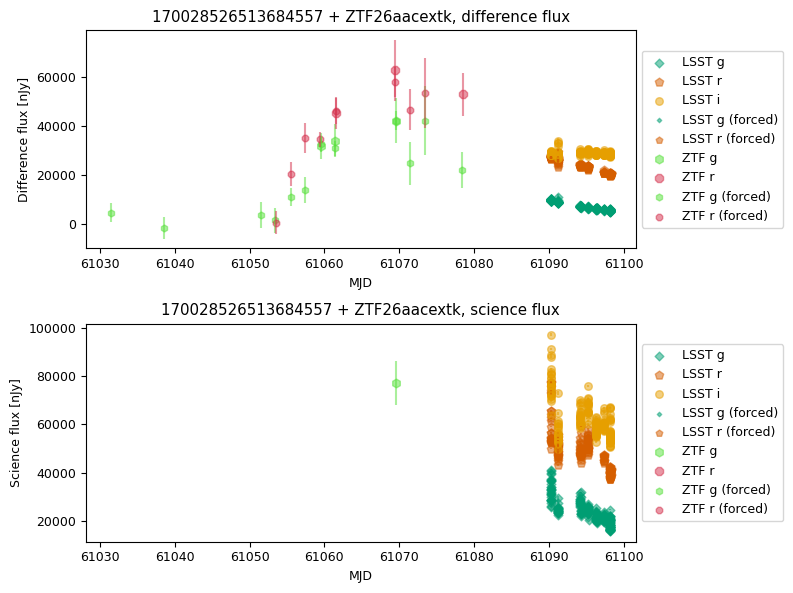

In [83]:
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_forced'] = True
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_forced'] = True

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

We can show these light curves using magnitude units

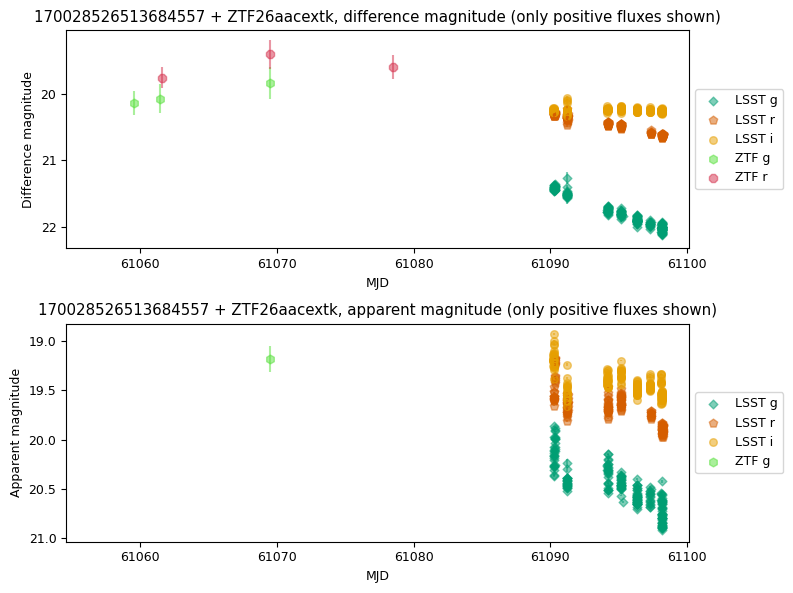

In [84]:
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_flux'] = False
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_forced'] = False

d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_flux'] = False
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_forced'] = False

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

We can also show them using absolute magnitudes, assuming the redshift of the tentative host and the Planck 2018 cosmology

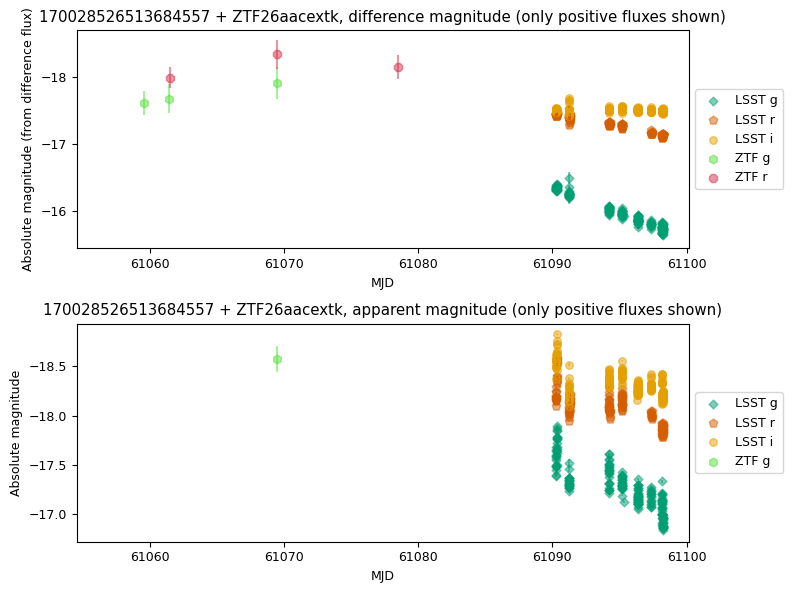

In [85]:
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_absolute_mag'] = True
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['z_obj'] = z_obj
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['cosmo'] = Planck18

d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_absolute_mag'] = True
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['z_obj'] = z_obj
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['cosmo'] = Planck18

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

### Features <a class='anchor' id='features'></a>

We query the features computed by ALeRCE in each survey. For LSST this is done using TAP, while for ZTF is done through a direct connection to our database.

For LSST, note that we use integer identifiers for both feature names and LSST bands. We recover the original names using the mapping defined in the ```feature_name_lut``` and ```band``` lookup tables (LUTs) respectively.

In [86]:
table_name = 'feature_name_lut'

query = '''
SELECT
    *
FROM
    alerce_tap.%s
    WHERE
        tid = %d
''' % (table_name, tid)
df_feature_names = alerce_tap.search(query).to_table().to_pandas()

display(df_feature_names)

,feature_id,feature_name,created_date,sid,tid
0,0,u-g_mean,2026-02-13,1,1
1,1,u-g_max,2026-02-13,1,1
2,2,g-r_mean,2026-02-13,1,1
3,3,g-r_max,2026-02-13,1,1
4,4,r-i_mean,2026-02-13,1,1
...,...,...,...,...,...
141,141,z-W4,2026-02-13,1,1
142,142,y-W1,2026-02-13,1,1
143,143,y-W2,2026-02-13,1,1
144,144,y-W3,2026-02-13,1,1


In [87]:
query = '''
SELECT
    *
FROM
    alerce_tap.feature
WHERE
    oid = %d
    AND sid = %d
''' % (oid_lsst, sid_lsst)
df_ft_lsst = alerce_tap.search(query).to_table().to_pandas()

display(df_ft_lsst)

,oid,sid,feature_id,band,version,feature_value,updated_date
0,170028526513684557,1,2,0,1,1.315615,2026-03-04
1,170028526513684557,1,3,0,1,1.038762,2026-03-04
2,170028526513684557,1,4,0,1,0.228292,2026-03-04
3,170028526513684557,1,5,0,1,0.158628,2026-03-04
4,170028526513684557,1,12,0,1,0.808968,2026-03-04
...,...,...,...,...,...,...,...
258,170028526513684557,1,117,2,1,-0.744105,2026-03-04
259,170028526513684557,1,117,3,1,0.105211,2026-03-04
260,170028526513684557,1,118,1,1,24.089010,2026-03-04
261,170028526513684557,1,118,2,1,22.774665,2026-03-04


In [88]:
df_ft_lsst = add_mapped_column(
    df=df_ft_lsst,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)

In [89]:
df_ft_lsst = add_mapped_column(
    df=df_ft_lsst,
    df_lut=df_feature_names,
    col='feature_id',
    col_mapped='feature_name')

We show the list of features retrieved (note that features with NaN values are not stored)

In [90]:
pd.set_option('display.max_rows', None)
display(df_ft_lsst)
pd.set_option('display.max_rows', 30)

,oid,sid,feature_id,band,version,feature_value,updated_date,band_name,feature_name
0,170028526513684557,1,2,0,1,1.315615e+00,2026-03-04,None,g-r_mean
1,170028526513684557,1,3,0,1,1.038762e+00,2026-03-04,None,g-r_max
2,170028526513684557,1,4,0,1,2.282916e-01,2026-03-04,None,r-i_mean
3,170028526513684557,1,5,0,1,1.586284e-01,2026-03-04,None,r-i_max
4,170028526513684557,1,12,0,1,8.089678e-01,2026-03-04,None,g-r_mean_corr
5,170028526513684557,1,13,0,1,6.920177e-01,2026-03-04,None,g-r_max_corr
6,170028526513684557,1,14,0,1,2.599193e-01,2026-03-04,None,r-i_mean_corr
7,170028526513684557,1,15,0,1,2.432009e-01,2026-03-04,None,r-i_max_corr
8,170028526513684557,1,20,0,1,7.993832e+00,2026-03-04,None,Timespan
9,170028526513684557,1,21,0,1,-9.851729e-01,2026-03-04,None,Coordinate_x


For ZTF, we open the connection and do an SQL query and show the list of features retrieved

In [91]:
url = "https://raw.githubusercontent.com/alercebroker/usecases/master/alercereaduser_v4.json"
params = requests.get(url).json()['params']

In [92]:
engine = sa.create_engine('postgresql+psycopg2://' + params['user'] \
                          + ':' + params['password'] + '@' + params['host'] \
                          + '/' + params['dbname'])
conn_ztf = engine.connect()

In [93]:
query = '''
SELECT
    *
FROM
    feature
WHERE
    oid = '%s'
''' % oid_ztf

df_feat_ztf = pd.read_sql_query(query, conn_ztf)

pd.set_option('display.max_rows', None)
display(df_feat_ztf)
pd.set_option('display.max_rows', 30)

,oid,name,value,fid,version
0,ZTF26aacextk,g-r_mean,0.428631,12,27.5.6
1,ZTF26aacextk,g-r_max,0.427900,12,27.5.6
2,ZTF26aacextk,g-r_mean_corr,NaN,12,27.5.6
3,ZTF26aacextk,g-r_max_corr,NaN,12,27.5.6
4,ZTF26aacextk,W1-W2,NaN,0,27.5.6
5,ZTF26aacextk,W2-W3,NaN,0,27.5.6
6,ZTF26aacextk,W3-W4,NaN,0,27.5.6
7,ZTF26aacextk,g-W1,NaN,0,27.5.6
8,ZTF26aacextk,r-W1,NaN,0,27.5.6
9,ZTF26aacextk,g-W2,NaN,0,27.5.6


We close the connection

In [94]:
conn_ztf.close()

## Querying samples of objects <a class='anchor' id='query_many'></a>

The ALeRCE pipeline computes probabilities for different classifiers. At this time, we classify LSST objects using the ALeRCE stamp classifier (still in beta mode), which is a deep learning classifier based on each object's first alert image cutouts (manuscript in preparation; see [Carrasco-Davis et al. 2021](https://ui.adsabs.harvard.edu/abs/2021AJ....162..231C/abstract) for a similar version using the ZTF public alert stream). This classifier taxonomy includes five classes, and is used to pre-select transient candidates (e.g. supernovae, tidal disruption events) early after their first light.

Note that we use integer identifiers for both classifiers and their taxonomies. We recover the classifier and class names using the mapping defined in the ```classifier``` and ```taxonomy``` LUTs, respectively:

In [95]:
table_name = 'classifier'

query = '''
SELECT
    classifier_id, classifier_name, classifier_version, tid
FROM
    alerce_tap.%s
WHERE
    tid = %d
''' % (table_name, tid)

df_classifiers = alerce_tap.search(query).to_table().to_pandas()
display(df_classifiers)

,classifier_id,classifier_name,classifier_version,tid
0,1,stamp_classifier_rubin_beta,2.0.1,1


In [96]:
classifier_id = 1 # Stamp classifier

In [97]:
table_name = 'taxonomy'

query = '''
SELECT
    class_id, class_name, classifier_id
FROM
    alerce_tap.%s
WHERE
    classifier_id = %d
''' % (table_name, classifier_id)

df_tax_stamp = alerce_tap.search(query).to_table().to_pandas()
display(df_tax_stamp)

,class_id,class_name,classifier_id
0,0,SN,1
1,1,AGN,1
2,2,VS,1
3,3,asteroid,1
4,4,bogus,1


We search for 30 objects that had their first detection between Nov 1 2025 and Feb 25 2026, their last detection after Feb 5 2026, have 50 detections or more, and have the highest probability of being a supernova (SN) according to the stamp classifier, as

In [98]:
def utc_to_mjd(time):
    return Time(time, format='isot', scale='utc').mjd

In [99]:
firstmjd_min = utc_to_mjd('2025-11-01T00:00:00')
firstmjd_max = utc_to_mjd('2026-02-25T00:00:00')
print(firstmjd_min, firstmjd_max)

lastmjd_min = utc_to_mjd('2026-02-05T00:00:00')
print(lastmjd_min)

class_id = 0 # SN
n_det_min = 50
n_objs = 30

60980.0 61096.0
61076.0


In [100]:
query = '''
SELECT TOP %d
    obj.*,
    prob.*
FROM
    alerce_tap.object AS obj
JOIN
    alerce_tap.probability AS prob
ON
    obj.oid = prob.oid
    AND obj.sid = prob.sid
WHERE
    obj.firstmjd >= %g
    AND obj.firstmjd < %g
    AND obj.lastmjd >= %g
    AND obj.n_det >= %d
    AND prob.classifier_id = %d
    AND prob.class_id = %d
    AND prob.ranking = 1
ORDER BY prob.probability DESC
''' % (n_objs,
       firstmjd_min, firstmjd_max,
       lastmjd_min, n_det_min,
       classifier_id, class_id)
df_objs = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'lastmjd_']
df_objs.drop(columns=cols, inplace=True)

We recover both classifier and class names as

In [101]:
df_objs = add_mapped_column(
    df=df_objs,
    df_lut=df_classifiers,
    col='classifier_id',
    col_mapped='classifier_name'
)

df_objs = add_mapped_column(
    df=df_objs,
    df_lut=df_tax_stamp,
    col='class_id',
    col_mapped='class_name'
)

In [102]:
display(df_objs)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date,classifier_id,classifier_version,class_id,probability,ranking,classifier_name,class_name
0,313893023122980956,1,1,62.081009,-46.931759,2.830006e-07,2.768487e-07,61033.284793,61095.094861,61.810069,150,184,0,2026-02-13,2026-02-24,1,201,0,0.995795,1,stamp_classifier_rubin_beta,SN
1,170028526873870371,1,1,186.808234,8.482416,6.333561e-08,6.659057e-08,61090.249392,61098.241373,7.991980,457,464,0,2026-02-19,2026-02-27,1,201,0,0.995368,1,stamp_classifier_rubin_beta,SN
2,313897384094990464,1,1,62.579228,-47.370058,2.821594e-07,2.775291e-07,61034.161767,61095.094861,60.933095,98,181,0,2026-02-13,2026-02-24,1,201,0,0.994967,1,stamp_classifier_rubin_beta,SN
3,170032925073997933,1,1,186.699774,7.671551,2.330104e-07,2.498458e-07,61090.267104,61095.218546,4.951442,99,172,0,2026-02-20,2026-02-24,1,201,0,0.994210,1,stamp_classifier_rubin_beta,SN
4,170019696272736349,1,1,61.497111,-49.245787,3.787772e-07,3.681736e-07,61088.098045,61101.030547,12.932502,454,492,0,2026-02-17,2026-03-02,1,201,0,0.993127,1,stamp_classifier_rubin_beta,SN
5,170028526740701203,1,1,186.910111,8.014844,2.329281e-07,2.502883e-07,61090.248460,61098.241373,7.992913,387,570,0,2026-02-19,2026-02-27,1,201,0,0.992937,1,stamp_classifier_rubin_beta,SN
6,170028526579744777,1,1,185.020121,7.815352,1.161964e-07,1.204435e-07,61090.248460,61098.232175,7.983715,391,509,0,2026-02-19,2026-02-27,1,201,0,0.992041,1,stamp_classifier_rubin_beta,SN
7,170028526652096607,1,1,187.270931,7.253687,9.786403e-07,1.066702e-06,61090.248460,61098.210024,7.961564,110,509,0,2026-02-19,2026-02-27,1,201,0,0.991492,1,stamp_classifier_rubin_beta,SN
8,170028527303262373,1,1,187.404372,7.932739,4.287842e-07,4.381176e-07,61090.250794,61095.217021,4.966226,63,196,0,2026-02-20,2026-02-24,1,201,0,0.990184,1,stamp_classifier_rubin_beta,SN
9,170028485948473400,1,1,64.230276,-47.771431,3.283262e-07,3.185615e-07,61090.048455,61095.089601,5.041146,66,167,0,2026-02-19,2026-02-24,1,201,0,0.990077,1,stamp_classifier_rubin_beta,SN


Note that for each object we compute probabilities in all taxonomy classes, but in this query we were interested only in their most likely class, thus we asked for ```ranking = 1``` probabilities only.

We display their mean coordinates, as well as some of their properties

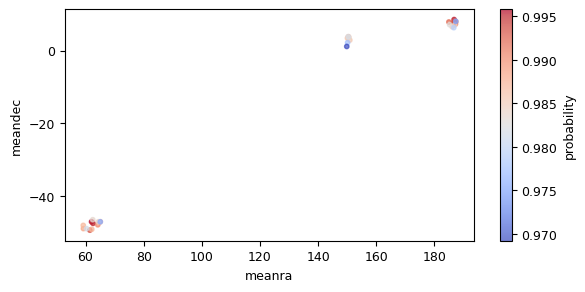

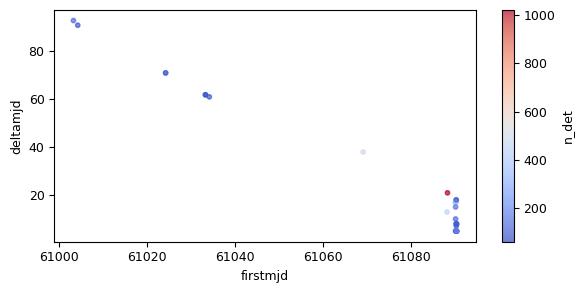

In [103]:
props_x = ['meanra', 'firstmjd']
props_x = [x.lower() for x in props_x]
props_y = ['meandec', 'deltamjd']
props_y = [x.lower() for x in props_y]
props_color = ['probability', 'n_det']
props_color = [x.lower() for x in props_color]

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_objs,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color)

We generate their Explorer link

In [104]:
print_link_lsst(index=df_objs['oid'])

### Object lists <a class='anchor' id='query_list'></a>

Note that we can also search by a list of known object identifiers

In [105]:
sid = 1
oids = [
    313853517490028563,
    313695087485255753,
    313853517444939794,
]

In [106]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    sid = %d
    AND oid IN (%s)
''' % (sid, ','.join(["'%s'" % oid for oid in oids]))

df_objs = alerce_tap.search(query).to_table().to_pandas()
display(df_objs)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,313853517444939794,1,1,149.738956,2.220690,1.583264e-07,1.593740e-07,61024.245933,61109.144737,84.898804,1230,1030,0,2026-02-13,2026-03-10
1,313853517490028563,1,1,150.021002,0.550432,2.819574e-07,2.861040e-07,61024.245933,61108.085916,83.839984,707,566,0,2026-02-13,2026-03-09
2,313695087485255753,1,1,10.240460,-43.631763,9.990519e-07,9.716947e-07,60988.123073,61069.080680,80.957607,140,0,0,2026-02-13,2026-02-24


We generate their Explorer link

In [107]:
print_link_lsst(index=df_objs['oid'])

### Querying detections for larger samples <a class='anchor' id='query_detections_many'></a>

We query the detections for all these objects altogether. For this we define a function that splits the call in smaller chunks, useful for longer object lists

In [108]:
def find_detections(chunk_size=100, index=None, sid=None,
                    maxrec = int(5e5)):
    bin_ids = np.arange(int(np.ceil(len(index) / chunk_size)))
    #print(str(len(bin_ids)) + ' chunks')
    df = pd.DataFrame()
    
    for idx in bin_ids:
        #print('Chunk ' + str(idx))
        index_i = idx * chunk_size
        index_f = (idx + 1) * chunk_size
        names = np.array(index)[index_i:index_f].tolist()
        
        query = '''
        SELECT
            det.*,
            lsst_det.*
        FROM
            alerce_tap.detection AS det
        JOIN
            alerce_tap.lsst_detection AS lsst_det
        ON
            det.oid = lsst_det.oid
            AND det.sid = lsst_det.sid
            AND det.measurement_id = lsst_det.measurement_id
        WHERE
            det.sid = %d
            AND lsst_det.oid IN (%s)
        ''' % (sid, ','.join(["'%s'" % oid for oid in names]))
        df_aux = alerce_tap.search(query, maxrec=maxrec).to_table().to_pandas()
        
        cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
        df_aux.drop(columns=cols, inplace=True)

        df = pd.concat([df, df_aux], axis=0)
        del df_aux

    return df

In [109]:
index = df_objs['oid']
df_dets = find_detections(index=index, sid=sid)

In [110]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

In [111]:
display(df_dets[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
313695087485255753,1,313695087485255753,r,60988.123073,2245.923828,184.483780,9142.951172,186.544113
313695087485255753,1,313695087641493513,r,60988.123535,1952.115723,177.136139,8823.225586,177.510422
313695087485255753,1,313699505037901848,g,60989.204733,1694.385010,187.466080,7923.849609,190.901917
313695087485255753,1,313708285431119933,g,60991.237160,1547.964478,169.927643,7639.310059,173.533829
313695087485255753,1,313708285541220407,g,60991.237618,1604.303223,187.784409,8293.083984,192.200287
...,...,...,...,...,...,...,...,...
313853517490028563,1,314011776892534797,z,61060.298492,4638.598633,379.880798,20550.980469,362.704407
313853517490028563,1,314011777026752530,z,61060.298890,5069.586914,383.087738,20808.773438,367.057953
313853517490028563,1,314011777160970253,z,61060.299997,4385.311035,357.484863,20088.320312,343.792053


We show the light curves using flux densities and magnitudes

In [112]:
df_dets.rename(columns={
    'psfflux': 'psfFlux',
    'psffluxerr': 'psfFluxErr',
    'scienceflux': 'scienceFlux',
    'sciencefluxerr': 'scienceFluxErr',
}, inplace=True)

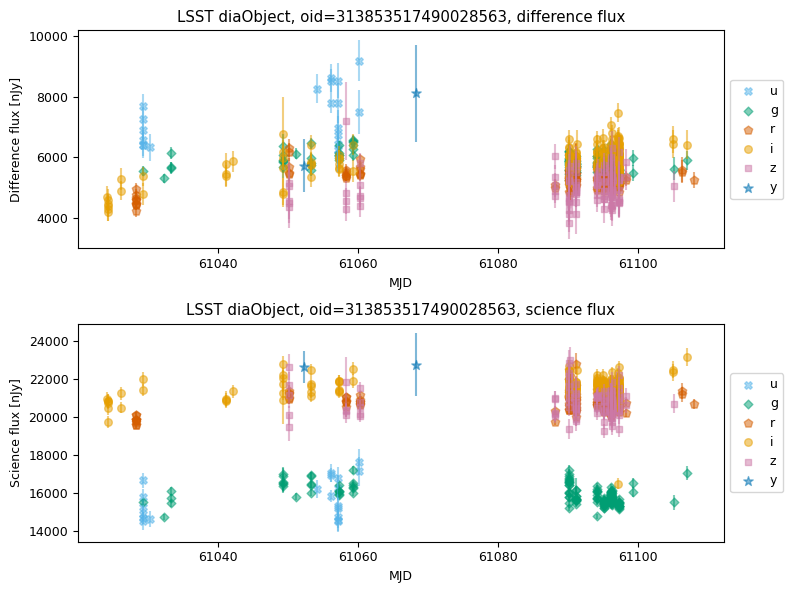

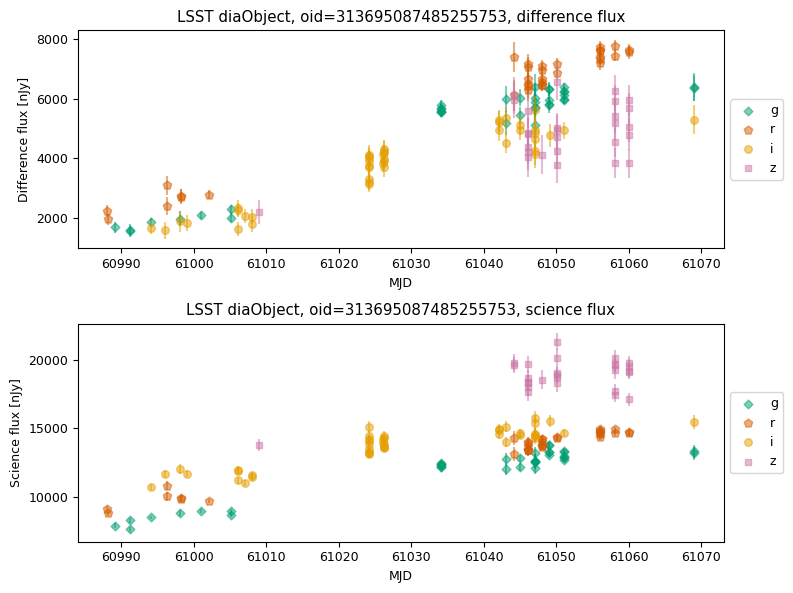

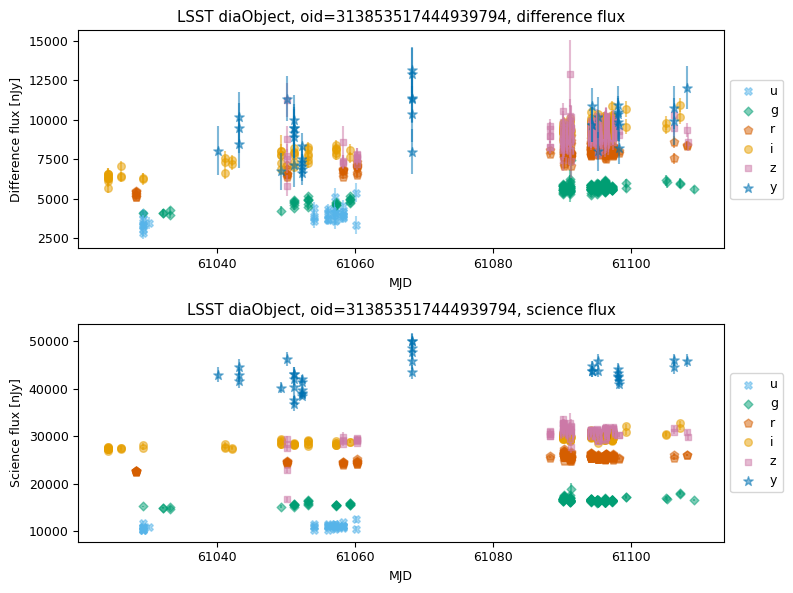

In [113]:
for oid in oids:
    d_objs = ms.group_data_sid_oid(
        sid=sid,
        oid=oid,
        df_dets=df_dets.loc[oid].copy(),
        lc_kwargs=ms.init_lc_kwargs()
    )
    ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

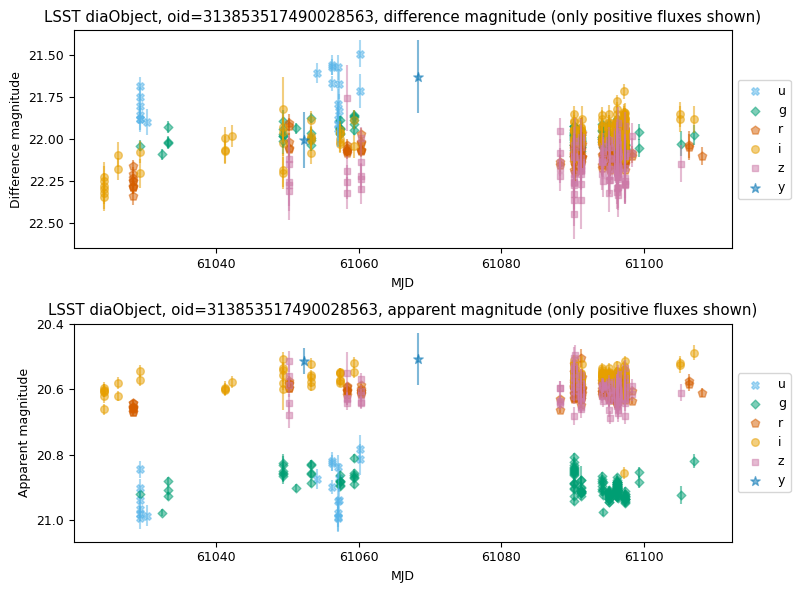

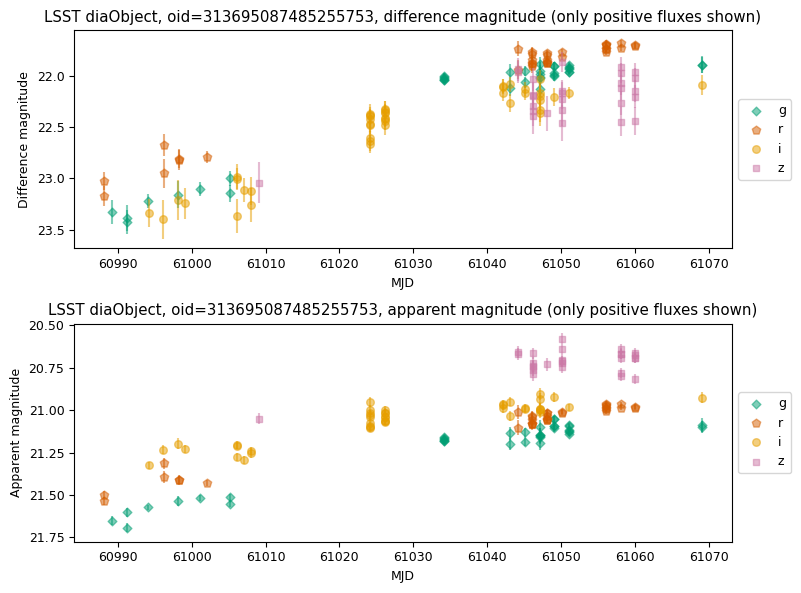

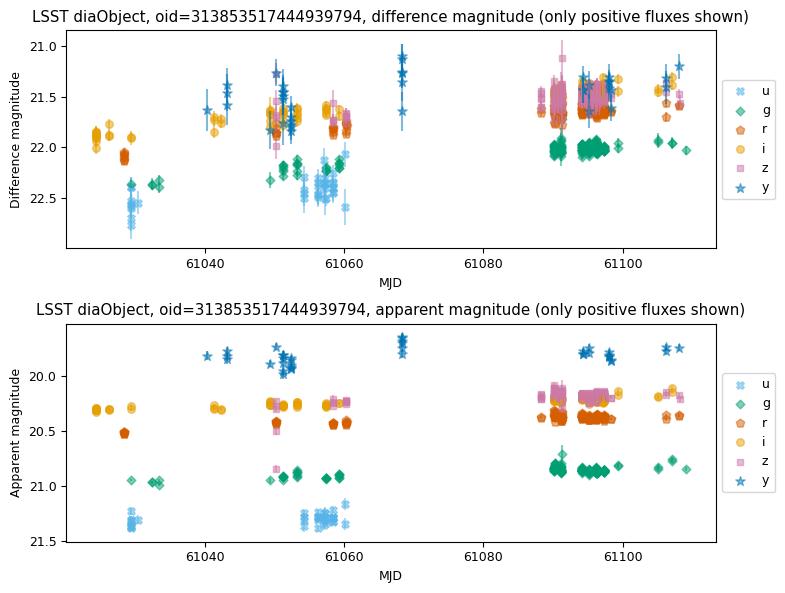

In [114]:
for oid in oids:
    d_objs = ms.group_data_sid_oid(
        sid=sid,
        oid=oid,
        df_dets=df_dets.loc[oid].copy(),
        lc_kwargs=ms.init_lc_kwargs()
    )
    d_objs[sid][oid]['lc_kwargs']['show_flux'] = False
    ms.plot_lc(d_objs=d_objs, lc_params=lc_params)